# [실습] 사고 경험률 표 — 믿을 수 있는 세그먼트 구분

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 오늘의 질문과 데이터

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">모형추정 심화통계 · Day 1</div>
<h1 style="color:#000000;margin:10px 0">사고 경험률 표 — 믿을 수 있는 세그먼트 구분</h1>
<div style="font-size:1.05em;color:#656565">프랑스 자동차보험 실계약 678,013건에서 요율표에 그대로 적을 세그먼트를 구분합니다</div>
</div>

## 오늘 할 일

여러분은 자동차보험사의 **프라이싱(요율 산정) 분석가**입니다. 오늘의 질문은 하나예요 — **"계약 하나가 사고를 겪을 확률을 우리 기록에서 가장 그럴듯하게 추정하면 얼마이고, 그 숫자를 요율표의 어느 세그먼트까지 그대로 옮겨 적어도 되는가."** **세그먼트** 는 지역·차종·마력 같은 조건의 조합 하나, 그리고 그 조합에 속한 계약 n건을 뜻합니다 — 요율표의 한 행이 세그먼트 하나예요. 이론에서 배운 우도와 최대우도추정(MLE)을 실계약 데이터에 그대로 적용합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Binomial_distribution_pmf.svg" width="560" height="373"/>
<p align="center"><em>▲ 계약 n 건 중 사고를 겪은 계약이 k 건일 확률 — 계약 20건에 사고 확률 0.5 이면 k = 10 이 가장 잦고(확률 0.176), 오늘은 반대로 관측된 k 에서 그 확률을 되짚는다 (출처: Wikimedia Commons, Binomial distribution pmf.svg)</em></p>

<details class="lms-extra"><summary>자세히 — 위 그림의 가로축과 색 읽는 법</summary>

가로축은 사고를 겪은 계약 수 k 이고, 세로축은 그 k 가 나올 확률입니다. 파랑과 초록은 계약 20건에서 사고 확률이 0.5 일 때와 0.7 일 때이고, 빨강은 같은 0.5 를 계약 40건에서 본 것입니다. 계약 하나가 0 또는 1 을 내놓는 이 구조가 오늘 다루는 데이터와 같습니다.

</details>

미션 셋으로 전체 값 하나에서 세그먼트별 값까지 내려가고, 세그먼트마다 판정을 붙이는 과제로 마무리합니다. 수업에서 함께 도는 것은 미션 1·2 와 정리이고, 미션 3 과 과제는 방과후 몫이에요.

## 오늘의 데이터

**freMTPL2freq** 는 프랑스 자동차 책임보험의 실제 계약 기록입니다. 계약 한 건이 한 행이고 678,013행 × 12컬럼이며, 공개 저장소 OpenML 에서 로그인 없이 내려받습니다. 처음 한 번은 내려받느라 조금 걸려요. 받자마자 아래 규칙 셋을 고정하고, 뒤쪽 미션은 여기에 지역 `Region` · 차종 `VehBrand` · 마력 등급 `VehPower` 셋을 세그먼트를 가르는 기준으로 더해 씁니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Japanese_car_accident.jpg" width="640" height="360"/>
<p align="center"><em>▲ 교차로 접촉 사고 — 오늘 다루는 데이터의 한 행 한 행은 이런 현장들의 기록이다. 계약이 사고를 겪을 확률을 역산해 요율표의 세그먼트를 채우는 것이 이번 실습의 목표 (출처: Wikipedia, Japanese_car_accident.jpg)</em></p>

| 컬럼 | 뜻 | 받자마자 고정하는 규칙 |
|---|---|---|
| `ClaimNb` | 보험 기간 중 사고(청구) 건수 (건) | 상한 4건에서 절사 — 네 건을 넘는 사고가 적힌 계약이 소수 섞여 있어, 그 몇 건이 전체 평균을 크게 왜곡하지 않도록 두는 관례적인 전처리입니다 |
| `Exposure` | 그 계약이 실제로 유지된 기간 (년) | 상한 1.0년에서 절사 — 1년을 넘겨 적힌 계약이 소수 섞여 있어 같은 이유로 자릅니다 |
| `HasClaim` | **사고를 겪었는가** (0 또는 1) | `ClaimNb > 0` 을 0/1 로 바꿔 새로 만듭니다 — 오늘 분석하는 변수가 이 한 열입니다. 이 열을 더하면 표가 13열이 되어, 미션 1 준비 셀은 `(678013, 13)` 을 찍습니다 |

오늘은 「몇 건을 냈는가」가 아니라 「겪었는가 아닌가」만 셉니다. 계약마다 유지 기간이 다른 것을 값에 반영하는 이야기는 내일 다시 꺼냅니다.

## 이 노트북을 쓰는 법

**환경 안내** — ▶ 실행은 Google Colab 연결 안내를 따르고, 튜터는 상단 「Claude 도우미」 설치 뒤 씁니다(온보딩 레슨 참고). **채점은 Colab 이 연결되면 자동으로 준비됩니다 — 코드 패널 머리의 「채점 준비됨」이 뜬 뒤 미션을 시작하고, 미션 셀을 실행했는데 채점 결과가 안 찍히면 그 「채점 준비됨」을 누르세요.**

노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 맨 위의 접힌 `[채점]` 셀을 한 번 ▶ 실행한 뒤 시작합니다(코드는 접혀 있어도 실행됩니다). 도우미 대신 아무 AI 에 PROMPT 를 붙여 넣어 받은 코드를 `# --- 여기부터 AI 코드 ---` 행 아래에 직접 붙입니다. 채점이 끝나 🔓 가 뜨면 그 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줍니다.

**맨 위 두 셀을 먼저 실행하세요 — 설치·폰트 셀은 한 번이면 되고, 채점 셀은 LMS 가 자동으로 실행합니다.** 미션마다 코드 셀이 둘입니다. 앞의 것은 **준비 셀** 이라 그대로 실행하고, 뒤의 것은 **PROMPT 셀** 이라 시킬 일을 적습니다. 「준비 셀」이 그 미션에 쓸 변수를 처음부터 만들어 주니, 뒤쪽 미션만 따로 열어도 그 셀부터 실행하면 됩니다.

PROMPT 셀의 `PROMPT` 에 시킬 일을 내 말로 적어 AI 에게 넘기면, `# --- 여기부터 AI 코드 ---` 행 아래가 AI 가 코드를 넣는 자리가 됩니다. 실행하는 순간 **실행 결과(출력)에 채점 결과**가 찍혀요. 기준에 닿으면 완성본 풀이가 열리고, 어긋나면 어긋난 자리와 튜터에 보낼 질문이 나옵니다. 변수 이름은 자유예요 — 채점은 이름이 아니라 출력과 그림을 봅니다.

**주고받기 규칙 둘** — AI 와 막혔을 때는 이 둘만 지킵니다.

| 이럴 때 | 이렇게 합니다 |
|---|---|
| 같은 말을 두 번째 되풀이하게 될 때 | 말을 바꾸지 말고 `PROMPT` 에 **빠진 조건을 하나** 더합니다 |
| 조건을 더해도 안 될 때 | 앞 대화를 이어 붙이지 말고, 요구를 한 덩어리로 다시 적어 새 메시지로 보냅니다 |

In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7" "seaborn>=0.13" "scikit-learn>=1.3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.optimize import minimize
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True                            # 여백은 tight_layout 이 알아서
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     # 위 테두리·오른쪽 테두리·격자를 걷어내 데이터만 남긴다
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림들이 함께 쓰는 색 — 우도 곡선=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3", "참값": "#757575"}
FIG_W = 10.0     # 캔버스 폭은 모두 이 값으로 고정하고 높이만 그림마다 조절한다

print("사용 폰트:", FONT,
      "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [ ]:
#@title [채점] 이 셀을 먼저 실행하세요 (한 번이면 됩니다)
#   미션의 「PROMPT 셀」을 실행하면 그 셀의 출력과 그림을 받아 바로 아래에 채점을 찍습니다.
#   통과하면 그 자리에서 완성본 풀이가 열리고, 아니면 항목별 힌트와 튜터에 보낼 질문이 나옵니다.
#   읽지 않고 실행만 해도 됩니다 — 기대값과 풀이는 이 셀에만 있고 「PROMPT 셀」에는 없습니다.
import base64
import glob
import io
import json
import re
import shutil
import subprocess
import sys

import matplotlib.font_manager as fm      # 아래 폰트 자급이 쓴다
import matplotlib.pyplot as plt


def _font_bootstrap():
    """한글 폰트 자급 — 맨 위 설치·폰트 셀을 건너뛰어도 그래프의 한글이 깨지지 않게.

    LMS 는 이 셀만 자동 실행하므로 폰트 준비도 여기서 한 번 더 한다. 설치·폰트 셀과 같은
    규칙이라 둘 다 돌아도 결과가 같고, apt-get 이 없는 자리(로컬)에서는 곧바로 지나간다.
    설치한 ttf 는 `addfont` 로 폰트 목록에 직접 넣는다 — 넣지 않으면 목록이 옛 상태라
    한글이 □ 로 깨진다(2026-09-09 Colab 실사고).
    """
    try:
        cands = ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"]
        installed = {f.name for f in fm.fontManager.ttflist}
        if not any(n in installed for n in cands) and shutil.which("apt-get"):
            subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"],
                           check=False, timeout=120)
        # 설치는 파일만 만든다 — 이미 떠 있는 폰트 목록에 addfont 로 넣어야 이름이 보인다.
        # (설치를 건너뛴 자리도 나눔 ttf 가 이미 있으면 이 줄들만으로 잡힌다.)
        for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):
            try: fm.fontManager.addfont(_p)
            except Exception: pass
        try: fm._get_font.cache_clear()
        except Exception: pass
        installed = {f.name for f in fm.fontManager.ttflist}
        _font = next((n for n in cands if n in installed), "DejaVu Sans")
        plt.rcParams["font.family"] = _font
        plt.rcParams["axes.unicode_minus"] = _font in {"Pretendard", "DejaVu Sans"}
    except Exception:
        print("한글 폰트를 못 찾아 그래프 글자가 깨질 수 있습니다 —"
              " 맨 위 설치·폰트 셀을 실행하세요")


_font_bootstrap()


def _dec_json(s):                          # base64(JSON) → 값. 리스트는 원래 튜플이라 되돌립니다
    def _t(v):
        return ({k: _t(x) for k, x in v.items()} if isinstance(v, dict)
                else tuple(_t(x) for x in v) if isinstance(v, list) else v)
    return _t(json.loads(base64.b64decode(s).decode("utf-8")))


# 채점 기준 — base64(JSON), 통과 판정에만 쓴다
_ANS = _dec_json(
    "eyJtMSI6IHsidmFsdWVzIjogeyLsgqzqs6Ag6rK97ZeY66WgICjruYTsnKgpIjogWzAuMDQ5OTUsIDAuMDUwNTIsICLruYTsnK"
    "giXSwgIuyCrOqzoOulvCDqsqrsnYAg6rOE7JW9IOyImCAo6rG0KSI6IFszNDA1OS41LCAzNDA2MC41LCAi6rG0Il19LCAicGxv"
    "dCI6IHsia2luZCI6ICJsaW5lIiwgIm5fc2VyaWVzIjogMSwgInhfcmFuZ2UiOiBbMC4wMiwgMC4xXSwgInBlYWtfeCI6IFswLj"
    "A0OCwgMC4wNTNdLCAidmxpbmVfeCI6IFswLjA0OCwgMC4wNTNdLCAi7LaV652867KoIjogdHJ1ZX19LCAibTIiOiB7InZhbHVl"
    "cyI6IHsi6rOE7JW9IDQw6rG0IOyEuOq3uOuovO2KuOydmCDCsTJTRSAo67mE7JyoKSI6IFswLjA4MzA4LCAwLjA4MzUsICLruY"
    "TsnKgiXSwgIsKxMlNFIOulvCDqs4TsgrDtlaAg7IiYIOyXhuuKlCDshLjqt7jrqLztirgg7IiYICjqsJwpIjogWzc1OC41LCA3"
    "NTkuNSwgIuqwnCJdfSwgInBsb3QiOiB7ImtpbmQiOiAic2NhdHRlciIsICJuX3BvaW50cyI6IFsyMzAwLCAyNDAwXSwgInhzY2"
    "FsZSI6ICJsb2ciLCAieW1heCI6IFswLjk5LCAxLjAxXSwgIuy2leudvOuyqCI6IHRydWV9fSwgIm0zIjogeyJ2YWx1ZXMiOiB7"
    "IjYz6rG0IOyEuOq3uOuovO2KuCDsg4HrjIDsmrDrj4Qg6rWs6rCE7J2YIOyDge2VnCAo67mE7JyoKSI6IFswLjE0LCAwLjE0Mj"
    "UsICLruYTsnKgiXSwgIuyghOyytCDqs4Tslb0g7IKs6rOgIOqyve2XmOuloOydmCDsg4HrjIDsmrDrj4QgKOu5hOycqCkiOiBb"
    "MC44OTU1LCAwLjkwMDcsICLruYTsnKgiXX0sICJwbG90IjogeyJraW5kIjogImxpbmUiLCAibl9zZXJpZXMiOiAyLCAieF9yYW"
    "5nZSI6IFswLjAsIDAuM10sICJ2bGluZV94IjogWzAuMDYsIDAuMDY3XSwgIuy2leudvOuyqCI6IHRydWV9fSwgIuqzvOygnCI6"
    "IHsidmFsdWVzIjogeyLqt7jrjIDroZwg7IKs7JqpIOyEuOq3uOuovO2KuCDsiJggKOqwnCkiOiBbOTU5LjUsIDk2MC41LCAi6r"
    "CcIl0sICLsnqzqsoDthqDCt+qzhOyCsCDrtojqsIAg7IS46re466i87Yq47JeQIOyGje2VnCDqs4Tslb0g7IiYICjqsbQpIjog"
    "WzI4NDgwLCAyODUwMCwgIuqxtCJdLCAi7J6s6rKA7YagIOyEuOq3uOuovO2KuCDspJEg6rOE7JW9IOyImOqwgCDqsIDsnqUg66"
    "eO7J2AIOyEuOq3uOuovO2KuOydmCDqs4Tslb0g7IiYICjqsbQpIjogWzE0Ni41LCAxNDcuNSwgIuqxtCJdLCAi6rOE7JW964u5"
    "IOyCrOqzoCDqsbTsiJggKOqxtC/qs4Tslb0pIjogWzAuMDUzMTIsIDAuMDUzMjQsICLqsbQv6rOE7JW9Il19LCAicGxvdCI6IH"
    "sia2luZCI6ICJzY2F0dGVyIiwgIm5fcG9pbnRzIjogWzIzMDAsIDI0MDBdLCAieHNjYWxlIjogImxvZyIsICJ5bWF4IjogWzAu"
    "NywgMC43Ml0sICLstpXrnbzrsqgiOiB0cnVlfX19")
_REVEAL = {"m1":                   # 완성본 풀이 — base64, 통과할 때만 디코드해 인쇄합니다
           "8J+UkyDrr7jshZggMSDsmYTshLHrs7gg4oCUIOOAjOyXrOq4sOu2gO2EsCBBSSDsvZTrk5zjgI0g7ZaJIOyVhOuemOyXkCDrk6"
           "TslrTsmKwg7L2U65Oc64qUIOydtCDsoJXrj4TsnoXri4jri6QKCuKWoCDsnbQg7L2U65Oc66W8IOu2gOuluCDtlITroaztlITt"
           "irgg7JiICgogICAg7J2066+4IOunjOuTpOyWtOyguCDsnojripQgeSwgbl9hbGwsIGJlcm5fbmxsIOydhCDqt7jrjIDroZwg7J"
           "Ow6rOgIOuLpOyLnCDrp4zrk6Tsp4DripQg66eQ7JWEIOykmC4g6rOE7JW9IOyghOyytOulvCDtlZwg642p7Ja066as66GcIOuG"
           "k+qzoCBiZXJuX25sbCDsnYQg6rCA7J6lIOyekeqyjAogICAg66eM65Oc64qUIOyCrOqzoCDqsr3tl5jrpaAgcCDrpbwg7IiY7L"
           "mYIOy1nOygge2ZlOuhnCDtlZjrgpjrp4wg7LC+7JWEIOykmC4g7LC+7J2AIOqwkuydgCAi7IKs6rOgIOqyve2XmOuloCA9ICjs"
           "iKvsnpApIOu5hOycqCIg7LKY65+8IOydtOumhOqzvCDri6jsnITrpbwg67aZ7JesIOyGjOyImCDsl6zshK8g7J6Q66as6rmM7K"
           "eACiAgICBwcmludCDtlZjqs6AsIHkg66W8IOyghOu2gCDrjZTtlZwg7IKs6rOg66W8IOqyquydgCDqs4Tslb0g7IiY64+EICLs"
           "gqzqs6Drpbwg6rKq7J2AIOqzhOyVvSDsiJggPSAo7Iir7J6QKSDqsbQiIOycvOuhnCDtlZwg7ZaJIOuNlCBwcmludCDtlbQg7K"
           "SYLiDqsJnsnYAg6rCS7J2EIGsg66W8IG4g7Jy866GcCiAgICDrgpjriKAg67CU66GcIOq1rO2VnCDqsoPqs7wg64KY656A7Z6I"
           "IOuGk+uKlCDtloksIOq3uOumrOqzoCDstZzsoIHtmZTqsIAg7IiY66C07ZaI64qU7KeA7JmAIOuwmOuztSDtmp/siJjrj4Qg7Z"
           "WcIO2WiSDssI3slrQg7KO86rOgLiDqt7jrnpjtlITripQg65SxIO2VnCDsnqXrp4wg6re466CkIOykmCDigJQg6rCA66Gc7LaV"
           "7JeQCiAgICDtm4Trs7QgcCDrpbwgMC4wMiDrtoDthLAgMC4xMCDquYzsp4Ag7LSY7LSY7Z6IIOuKmOyWtOuGk+qzoCDshLjroZ"
           "zstpXsnYAg6re4IOyekOumrOydmCDroZzqt7jsmrDrj4QoYmVybl9ubGwg7JeQIOuniOydtOuEiOyKpOulvCDrtpnsnbgg6rCS"
           "KeuhnCDqs6HshKDsnYQg7ZWY64KY66eMIOq3uOumsCDrkqQsCiAgICDrsKnquIgg7LC+7J2AIHAg7J6Q66as7JeQIOyImOynge"
           "yEoOydhCDtlZjrgpgg6riL6rOgIOqwgOuhnOy2leqzvCDshLjroZzstpXsl5Ag652867Ko7J2EIOuLrOyVhCDspJguCgogICAg"
           "cmVzID0gbWluaW1pemUoZnVuPWJlcm5fbmxsLCB4MD1bMC4wM10sIG1ldGhvZD0iTmVsZGVyLU1lYWQiKQogICAgcF9oYXQgPS"
           "BmbG9hdChyZXMueFswXSkKICAgIGtfaGF0ID0gZmxvYXQoeS5zdW0oKSkgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAg"
           "IyB5IOqwgCAwLzEg7J206528IO2VqeydtCDqs6cg7IKs6rOg66W8IOqyquydgCDqs4Tslb0g7IiYCiAgICBwcmludChmIuyCrO"
           "qzoCDqsr3tl5jrpaAgPSB7cF9oYXQ6LjZmfSDruYTsnKgiKQogICAgcHJpbnQoZiLsgqzqs6Drpbwg6rKq7J2AIOqzhOyVvSDs"
           "iJggPSB7a19oYXQ6LC4wZn0g6rG0IikKICAgIHByaW50KGYi6rO17Iud7Jy866GcIOq1rO2VnCDtlbQgay9uID0ge2tfaGF0IC"
           "8gbl9hbGw6LjZmfSDruYTsnKggKOyghOyytCDqs4Tslb0ge25fYWxsOix9IOqxtCkiKQogICAgcHJpbnQoIuyImOugtCIsIHJl"
           "cy5zdWNjZXNzLCAifCDrsJjrs7UiLCByZXMubml0LCAi7ZqMIHwg7LWc64yT6rCSIOyngOygkOydmCBOTEwiLCBmIntyZXMuZn"
           "VuOiwuMWZ9IikKCiAgICBjYW5kcyA9IG5wLmxpbnNwYWNlKDAuMDIsIDAuMTAsIDMwMCkgICAgICAgICAgICAgICAgICAjIOyC"
           "rOqzoCDqsr3tl5jrpaAg7ZuE67O0IDMwMOqwnAogICAgbG9nbGlrID0gbnAuYXJyYXkoWy1iZXJuX25sbCh2KSBmb3IgdiBpbi"
           "BjYW5kc10pICAgICAjIO2bhOuztOuniOuLpOydmCDroZzqt7jsmrDrj4QgKE5MTCDsnZgg67aA7Zi466W8IOuSpOynkeyKteuL"
           "iOuLpCkKICAgIGZpZywgYXggPSBwbHQuc3VicGxvdHMoZmlnc2l6ZT0oOCwgMy40KSkKICAgIGF4LnBsb3QoY2FuZHMsIGxvZ2"
           "xpaykKICAgIGF4LmF4dmxpbmUocF9oYXQsIGxzPSItLSIsIGNvbG9yPSJncmF5IikgICAgICAgICAgICAgIyDstZzrjJPqsJIg"
           "7KeA7KCQ7J2EIOqwgOumrO2CpOuKlCDsiJjsp4HshKAKICAgIGF4LnNldF94bGFiZWwoIu2bhOuztCDsgqzqs6Ag6rK97ZeY66"
           "WgIHAgKOu5hOycqCkiKQogICAgYXguc2V0X3lsYWJlbCgi66Gc6re47Jqw64+EIikKICAgIHBsdC5zaG93KCkKCu2VtOyEnQoK"
           "LSDstpzrsJzsoJDsnYQg7LWc64yT6rCSIOyngOygkOyXkOyEnCDtlZzssLgg65ao7Ja07KeEIDAuMDMg7JeQIOuSgOuKlOuNsO"
           "uPhCDsl7Tri6TshK8g67KIIOunjOyXkCDqsJnsnYAg6rCS7JeQIOuPhOywqe2VqeuLiOuLpC4g66Gc6re47Jqw64+E6rCAIOy1"
           "nOuMk+qwkuydtCDtlZjrgpjrv5Dsnbgg66ek64GI7ZWcIOqzoeyEoOydtOudvCDsi5zsnpHsoJDsnbQg7Ja065SU65OgIOqwme"
           "ydgCDri7XsnLzroZwg66qo7Jes7JqULgotIOqzteyLneycvOuhnCDrsJTroZwg6rWs7ZWY64qUIO2VtChjbG9zZWQtZm9ybSkg"
           "ay9uIOqzvCDsiJjsuZgg7LWc7KCB7ZmUIOqwkuydgCDshozsiJgg64uk7ISv7Ke4IOyekOumrOq5jOyngCDqsJnsirXri4jri6"
           "QuIOyXrOyEr+ynuCDsnpDrpqzsl5DshJwg6rCI66as64qUIOqyg+ydgCDstZzsoIHtmZTqsIAg44CM7J2066eM7ZWY66m0IOuQ"
           "kOuLpOOAjeqzoCDrqYjstpTripQg7ZeI7Jqp7Jik7LCoIOuVjOusuOydtOyngCDri6Trpbgg64u17JeQIOuPhOywqe2VnCDqso"
           "PsnbQg7JWE64uI7JeQ7JqULiDri6Trpbgg6ri466GcIO2VnCDrsogg642UIOq1rO2VtCDqsqzso7zripQg6rKD7J20IOyImOy5"
           "mCDstZzsoIHtmZTrpbwg7ZmV7J247ZWY64qUIOqwgOyepSDruaDrpbgg67Cp67KV7J6F64uI64ukLgotIOu2hOuqqOuKlCDsoI"
           "TssrQg6rOE7JW9IOyImOyeheuLiOuLpC4g6rCZ7J2AIOuNsOydtO2EsOuhnCDqs4Tslb3ri7kg7IKs6rOgIOqxtOyImCjsgqzq"
           "s6Ag6rG07IiY7J2YIO2VqSDDtyDqs4Tslb0g7IiYKeulvCDsnqzrqbQgMC4wNTMyIOudvOuKlCDri6Trpbgg7Iir7J6Q6rCAIO"
           "uCmOyYpOuKlOuNsCwg6re46rKD7J2AIOOAjOyCrOqzoOulvCDqsqrsl4jripTqsIDjgI3qsIAg7JWE64uI6528IOOAjOuqhyDq"
           "sbTsnYQg64OI64qU6rCA44CN66W8IOyerOuKlCDsp4DtkZzrnbwg7Jik64qY7J2YIOyniOusuOqzvCDri6jsnITqsIAg64uk66"
           "aF64uI64ukLiDrkZAg7KeA7ZGc6rCAIOyWtOuUlOyEnCDqsIjrpqzripTsp4DripQg6rO87KCc7JeQ7IScIOuLpOyLnCDrp4zr"
           "gqnri4jri6QuCi0g7LWc64yT6rCSIOyngOygkOydmCBOTEwg6rCSIOyekOyytOuKlCDrqqjtmJXsnZgg7KKL6rOgIOuCmOyBqO"
           "ydhCDsnqzripQg7KeA7ZGc6rCAIOyVhOuLmeuLiOuLpC4g6rOE7JW9IO2VmOuCmO2VmOuCmOydmCDroZzqt7jtmZXrpaDsnYQg"
           "Njfrp4wg67KIIOuEmOqyjCDrjZTtlZwg6rCS7J206528IO2RnOuzuOydtCDtgazrqbQg6rCZ7J20IOy7pOyngOqxsOuToOyalC"
           "4g6rCZ7J2AIOuNsOydtO2EsCDsnITsl5DshJwg7ZuE67O064G866asIOqyrOykhCDrlYzrp4wg65y77J20IOyDneq5geuLiOuL"
           "pC4KLSDsmpTsnKgg67O06rOg7ISc7J2YIOyyqyDrrLjsnqXsnYAg7J2066CH6rKMIOyUgeuLiOuLpCDigJQgIuuLueyCrCDqs4"
           "Tslb0g7ZWcIOqxtOydtCDrs7Ttl5gg6riw6rCEIOykkSDsgqzqs6Drpbwg6rKq7J2EIO2ZleuloOydgCDslb0gNS4wJSDroZwg"
           "7LaU7KCV65CoLiDqt7zqsbA6IOuyoOultOuIhOydtCDstZzrjIDsmrDrj4TstpTsoJUsIOqzhOyVvSA2N+unjCA47LKcIOqxtC"
           "4iCgrsvZTrk5zqsIAg64u17J2EIOunjOuTnOuKlCDrsKnsi50g4oCUIOyCrOqzoOulvCDqsqrsnYAg6rOE7JW9IOyImOulvCDs"
           "oITssrQg6rOE7JW9IOyImOuhnCDrgpjriJXri4jri6QoPSDrsqDrpbTriITsnbQg7J2M7J2YIOuhnOq3uOyasOuPhOulvCDqsI"
           "DsnqUg7J6R6rKMIOunjOuTnOuKlCBwIOulvCDssL7sirXri4jri6QpLgo=",
           "m2":
           "8J+UkyDrr7jshZggMiDsmYTshLHrs7gg4oCUIOqzoOy5oCDqs7PsnYAg44CM7Jes6riw67aA7YSwIEFJIOy9lOuTnOOAjSDtlo"
           "kg7JWE656YIOuUsSDtlZwg7ZaJ7J6F64uI64ukCgrilqAg7J20IOy9lOuTnOulvCDrtoDrpbgg7ZSE66Gs7ZSE7Yq4IOyYiAoK"
           "ICAgIOyVhOuemCDsvZTrk5zsl5DshJwgwrEyU0Ug66W8IOyEuOuKlCDtlonsnbQg7IKs6rOg6rCAIDDqsbTsnbgg7IS46re466"
           "i87Yq47JeQ64+EIDAg7J2EIOuPjOugpOyjvOuKlCDqsowg66y47KCc7JW8LiDsgqzqs6DqsIAgMOqxtOydtOqxsOuCmCDqs4Ts"
           "lb0g7KCE67aA6rCAIOyCrOqzoOulvCDqsqrsnYAg7IS46re466i87Yq464qUCiAgICDCsTJTRSDrpbwg6rOE7IKw7ZWgIOyImC"
           "Dsl4bripQg7IS46re466i87Yq466GcIOuUsOuhnCDshLjqs6Ag7Iic7JyE7JeQ7IScIOu5vCDspJguIOydtOuvuCDrp4zrk6Ts"
           "lrTsoLgg7J6I64qUIHNlZzMg7JmAIHBfYWxsIOydhCDqt7jrjIDroZwg7JOw6rOgIO2RnOulvCDri6Tsi5wg66eM65Ok7KeA64"
           "qUIOunkOyVhCDspJguCiAgICDqs4Tslb0gNDDqsbTCt+yCrOqzoCAz6rG0IOyEuOq3uOuovO2KuOuKlCBuIOqzvCBrIOuhnCDs"
           "p4HsoJEg6rOo65287IScIOq3uCDshLjqt7jrqLztirjsnZggwrEyU0Ug66W8ICLqs4Tslb0gNDDqsbQg7IS46re466i87Yq47J"
           "2YIMKxMlNFID0gKOyIq+yekCkg67mE7JyoIiDsspjrn7wg7IaM7IiYIOyXrOyErwogICAg7J6Q66as6rmM7KeAIHByaW50IO2V"
           "mOqzoCwgwrEyU0Ug66W8IOqzhOyCsO2VoCDsiJgg7JeG64qUIOyEuOq3uOuovO2KuOqwgCDrqocg6rCc7J247KeA64+EICLCsT"
           "JTRSDrpbwg6rOE7IKw7ZWgIOyImCDsl4bripQg7IS46re466i87Yq4IOyImCA9ICjsiKvsnpApIOqwnCIg66GcIO2VnCDtlokg"
           "642UCiAgICBwcmludCDtlbQg7KSYLiDCsTJTRSDqsIAg7KKB7J2AIOyInOyEnCDri6TshK8g7ZaJ64+EIOq3uOuMgOuhnCDrgq"
           "jqsqgg65GQ6rOgLiDqt7jrnpjtlITripQg65SxIO2VnCDsnqXrp4wg6re466CkIOykmCDigJQg6rCA66Gc7LaV7J2AIOyEuOq3"
           "uOuovO2KuOydmCDqs4Tslb0g7IiY66W8IOuhnOq3uCDriIjquIjsl5AsCiAgICDshLjroZzstpXsnYAg6re4IOyEuOq3uOuovO"
           "2KuOydmCDsgqzqs6Ag6rK97ZeY66Wg66GcIOyEuOq3uOuovO2KuOuniOuLpCDsoJAg7ZWY64KY7JSpIOywjeydgCDsgrDsoJDr"
           "j4Tsl5Ag6rCA66Gc7LaV6rO8IOyEuOuhnOy2lSDrnbzrsqjsnYQg64us7JWEIOykmC4KCiAgICBpc191bm1lYXN1cmFibGUgPS"
           "Aoc2VnM1siayJdID09IDApIHwgKHNlZzNbImsiXSA9PSBzZWczWyJuIl0pICAgIyDCsTJTRSDrpbwg6rOE7IKw7ZWgIOyImCDs"
           "l4bripQg7KGw6rG0CiAgICBzZWczWyLtkZzspIDsmKTssKgiXSA9IDIgKiBucC5zcXJ0KHNlZzNbInBfbWxlIl0gKiAoMSAtIH"
           "NlZzNbInBfbWxlIl0pIC8gc2VnM1sibiJdKQogICAgc2VnMy5sb2NbaXNfdW5tZWFzdXJhYmxlLCAi7ZGc7KSA7Jik7LCoIl0g"
           "PSBucC5uYW4gICAgICAgICAgICAgICAgICAgICAgICAjIDAg7J20IOyVhOuLiOudvCDjgIzsl4bsnYzjgI0g7Jy866GcIOuRoe"
           "uLiOuLpAoKICAgIHNlZzQwID0gc2VnM1soc2VnM1sibiJdID09IDQwKSAmIChzZWczWyJrIl0gPT0gMyldLmlsb2NbMF0KICAg"
           "IHByaW50KGYi6rOE7JW9IDQw6rG0IOyEuOq3uOuovO2KuOydmCDCsTJTRSA9IHtzZWc0MFsn7ZGc7KSA7Jik7LCoJ106LjZmfS"
           "DruYTsnKgiKQogICAgcHJpbnQoZiLCsTJTRSDrpbwg6rOE7IKw7ZWgIOyImCDsl4bripQg7IS46re466i87Yq4IOyImCA9IHtp"
           "bnQoaXNfdW5tZWFzdXJhYmxlLnN1bSgpKX0g6rCcIikKCiAgICBuYXJyb3dfc2VfZmlyc3QgPSBzZWczLmxvY1t+aXNfdW5tZW"
           "FzdXJhYmxlICYgKHNlZzNbIm4iXSA8PSA2MyldLnNvcnRfdmFsdWVzKCLtkZzspIDsmKTssKgiKQogICAgcHJpbnQobmFycm93"
           "X3NlX2ZpcnN0LmhlYWQoNSlbWyJSZWdpb24iLCAiVmVoQnJhbmQiLCAiVmVoUG93ZXIiLCAibiIsICJrIiwgInBfbWxlIiwgIu"
           "2RnOykgOyYpOywqCJdXS50b19zdHJpbmcoaW5kZXg9RmFsc2UpKQoKICAgIGZpZywgYXggPSBwbHQuc3VicGxvdHMoZmlnc2l6"
           "ZT0oOCwgMy40KSkKICAgIGF4LnNjYXR0ZXIoc2VnM1sibiJdLCBzZWczWyJwX21sZSJdLCBzPTEwKQogICAgYXguc2V0X3hzY2"
           "FsZSgibG9nIikKICAgIGF4LnNldF94bGFiZWwoIuyEuOq3uOuovO2KuOydmCDqs4Tslb0g7IiYICjqsbQsIOuhnOq3uCDriIjq"
           "uIgpIikKICAgIGF4LnNldF95bGFiZWwoIuyCrOqzoCDqsr3tl5jrpaAgKOu5hOycqCkiKQogICAgcGx0LnNob3coKQoK7ZW07I"
           "SdCgotIOyghOyehOyekCDsvZTrk5zsnZgg7JuQ7J247J2AIO2VmOuCmOyYgOyKteuLiOuLpC4g7IKs6rOg6rCAIDDqsbTsnbgg"
           "7IS46re466i87Yq47JeQ7IScIHDMgiDsnbQgMCDsnbQg65CY6rOgLCDCsTJTRSDqs7Xsi53sl5AgMCDsnYQg64Sj7Jy866m0IO"
           "qysOqzvOuPhCAwIOydtCDrgpjsmLXri4jri6QuIOqzhOyCsOydtCDsi6TtjKjtlZwg6rKD7J20IOyVhOuLiOudvCDjgIzstpTs"
           "oJXqsJLsnbQg7ZGc67O47JeQIOuUsOudvCDri6zrnbzsp4Dsp4Ag7JWK64qU64uk44CN64qUIOqwkuydtCDsoJXsg4HsnLzroZ"
           "wg64+M7JWE7JioIOqyg+ydtOudvCBgaXNuYSgpYCDroZzripQg7ZWcIOqwnOuPhCDsnqHtnojsp4Ag7JWK7JWY7Ja07JqULgot"
           "IOq3uOuemOyEnCDjgIzCsTJTRSDqsIAg6rCA7J6lIOyigeydgCDshLjqt7jrqLztirjjgI0g7Iic7JyEIOunqCDslZ7snbQg7K"
           "CE67aAIOyCrOqzoCAw6rG0IOyEuOq3uOuovO2KuOuhnCDssYTsm4zsoYzsirXri4jri6QuIOyalOycqO2RnOyXkOyEnCDqsIDs"
           "nqUg7ZmV7Iuk7ZWcIOyEuOq3uOuovO2KuOuhnCDsmKzrnbzsmKgg6rKD7J20IOyLpOydgCDqs4Tslb0g7IiY6rCAIOqwgOyepS"
           "DsoIHsnYAg7IS46re466i87Yq47JiA642YIOyFiOydtOyXkOyalC4KLSDqs6DsuZwg65Kk7JeQ64qUIOqzhOyVvSA0MOqxtMK3"
           "7IKs6rOgIDPqsbQg7IS46re466i87Yq47J2YIMKxMlNFIOqwgCDqt7gg7IS46re466i87Yq47J2YIOyCrOqzoCDqsr3tl5jrpa"
           "AoMC4wNzUp67O064ukIOuEk+qyjCDrgpjsmLXri4jri6QuIMKxMlNFIOqwgCDstpTsoJXqsJLrs7Tri6Qg64ST7Jy866m0IOq3"
           "uCDshLjqt7jrqLztirjsnZgg7Iir7J6Q64qUIOyalOycqCDri6jsnIQg7JyE7JeQ7IScIOyWtOuKkCDqsJLsnbTrnbzqs6Ag66"
           "eQ7ZWgIOyImCDsl4bsirXri4jri6QuCi0g7IKw7KCQ64+E7J2YIOyZvOyqvSDrgZ3snbQg7IS466Gc66GcIOq4uOqyjCDtnans"
           "lrTsp4Dqs6Ag7Jik66W47Kq97Jy866GcIOqwiOyImOuhnSDsooHslYTsp5Hri4jri6QuIOqzhOyVvSDsiJjqsIAg64qY66m0IM"
           "KxMlNFIOqwgCDspITslrTrk5zripQg6rKD7J20IOq3uOumvOycvOuhnCDrs7TsnbTripQg7J6Q66as7J206rOgLCDshLjroZzs"
           "tpUgMS4wIOyXkCDrtpnsnYAg7KCQIOyFi+ydtCDqs4Tslb0g7KCE67aA6rCAIOyCrOqzoOulvCDqsqrsnYAg7IS46re466i87Y"
           "q47J6F64uI64ukLgotIMKxMlNFIOulvCDqs4TsgrDtlaAg7IiYIOyXhuuKlCDshLjqt7jrqLztirjsl5Ag7IaN7ZWcIOqzhOyV"
           "veydgCDsoITssrTsnZggMS4zNCUg67+Q7J6F64uI64ukLiDshLjqt7jrqLztirgg7IiY66Gc64qUIDPrtoTsnZggMSDsl5Ag6r"
           "CA6rmd7KeA66eMIOqzhOyVvSDsiJjroZzripQg7Ja866eIIOuQmOyngCDslYrslYTsmpQg4oCUIOqzhOyVvSDsiJjqsIAg7KCB"
           "7J2AIOyEuOq3uOuovO2KuOqwgCDrp47ri6TripQg66eQ6rO8IOq3uCDshLjqt7jrqLztirjqsIAg7YGs64uk64qUIOunkOydgC"
           "Dri6TrpoXri4jri6QuCgrsvZTrk5zqsIAg64u17J2EIOunjOuTnOuKlCDrsKnsi50g4oCUIOyCrOqzoOqwgCAw6rG07J206rGw"
           "64KYIOyghOu2gOyduCDshLjqt7jrqLztirjrpbwg66i87KCAIOqzqOudvCDjgIzCsTJTRSDsl4bsnYzjgI3snLzroZwg67m8IO"
           "uRkOqzoCwg64Ko7J2AIOyEuOq3uOuovO2KuOyXkOyEnOunjCDCsTJTRSDrpbwg7IS47Ja0IOyInOychOulvCDrp6TquYHri4jr"
           "i6QuCg==",
           "m3":
           "8J+UkyDrr7jshZggMyDsmYTshLHrs7gg4oCUIOOAjOyXrOq4sOu2gO2EsCBBSSDsvZTrk5zjgI0g7ZaJIOyVhOuemOyXkCDrk6"
           "TslrTsmKwg7L2U65Oc64qUIOydtCDsoJXrj4TsnoXri4jri6QKCuKWoCDsnbQg7L2U65Oc66W8IOu2gOuluCDtlITroaztlITt"
           "irgg7JiICgogICAg7J2066+4IOunjOuTpOyWtOyguCDsnojripQgc2VnMywgQzYzLCBDQklHLCBwX2FsbCDsnYQg6re464yA66"
           "GcIOyTsOqzoCDri6Tsi5wg66eM65Ok7KeA64qUIOunkOyVhCDspJguIO2bhOuztCDsgqzqs6Ag6rK97ZeY66Wg7J2EIDAuMDAx"
           "IOu2gO2EsCAwLjMwIOq5jOyngCDqsqnsnpDsoJAKICAgIDIsMDAx6rCc66GcIOy0mOy0mO2eiCDripjslrTrhpPqs6AsIEM2My"
           "Dqs7wgQ0JJRyDrkZAg7IS46re466i87Yq47JeQ7IScIO2bhOuztOuniOuLpCDsg4HrjIDsmrDrj4Qo6re4IO2bhOuztOydmCDs"
           "mrDrj4Trpbwg6re4IOyEuOq3uOuovO2KuCDstZzrjJPqsJLsnZgg7Jqw64+E66GcIOuCmOuIiCDqsJIp66W8CiAgICDqs4Tsgr"
           "DtlbQg7KSYLiDsg4HrjIDsmrDrj4TqsIAgZXhwKC0xLjkyKSDsnbTsg4Hsnbgg7ZuE67O066eMIOuCqOqyqCBDNjMg7Kq9IOq1"
           "rOqwhOydmCDsnITsqr0g64Gd7J2EICI2M+qxtCDshLjqt7jrqLztirgg7IOB64yA7Jqw64+EIOq1rOqwhOydmCDsg4HtlZwgPS"
           "Ao7Iir7J6QKSDruYTsnKgiIOyymOufvAogICAg7IaM7IiYIOyXrOyEryDsnpDrpqzquYzsp4AgcHJpbnQg7ZWY6rOgLCBDNjMg"
           "7JeQ7IScIHBfYWxsIOyekOumrOydmCDsg4HrjIDsmrDrj4Trj4QgIuyghOyytCDqs4Tslb0g7IKs6rOgIOqyve2XmOuloOydmC"
           "Dsg4HrjIDsmrDrj4QgPSAo7Iir7J6QKSDruYTsnKgiIOuhnCDtlZwg7ZaJIOuNlCBwcmludAogICAg7ZW0IOykmC4g6re4656Y"
           "7ZSE64qUIOuUsSDtlZwg7J6l66eMIOq3uOugpCDspJgg4oCUIOqwgOuhnOy2leydgCDtm4Trs7Qg7IKs6rOgIOqyve2XmOuloC"
           "wg7IS466Gc7LaV7J2AIOyDgeuMgOyasOuPhOuhnCDrkZAg7IS46re466i87Yq47J2YIOqzoeyEoOydhCDqsIHqsIEg7ZWY64KY"
           "7JSpIOq3uOumrOqzoCwKICAgIEM2MyDsnZgg7IKs6rOgIOqyve2XmOuloCDsnpDrpqzsl5Ag7IiY7KeB7ISg7J2EIO2VmOuCmC"
           "wgZXhwKC0xLjkyKSDrhpLsnbTsl5Ag6rCA66Gc7ISg7J2EIO2VmOuCmCDslrnsnYAg65KkIOuRkCDstpXsl5Ag652867Ko6rO8"
           "IOuylOuhgOulvCDri6zslYQg7KSYLgoKICAgIGNhbmRzID0gbnAubGluc3BhY2UoMC4wMDEsIDAuMzAsIDIwMDEpICAgICAgIC"
           "AgICAgICAgICMg7ZuE67O0IOyCrOqzoCDqsr3tl5jrpaAg6rKp7J6Q7KCQIDIsMDAx6rCcCgogICAgZGVmIHJlbF9saWsoc2Vn"
           "X3Jvdyk6CiAgICAgICAgbiwgayA9IGludChzZWdfcm93WyJuIl0pLCBpbnQoc2VnX3Jvd1siayJdKQogICAgICAgIGxvZ2xpay"
           "A9IGsgKiBucC5sb2coY2FuZHMpICsgKG4gLSBrKSAqIG5wLmxvZygxIC0gY2FuZHMpCiAgICAgICAgbWF4X2xsID0gayAqIG5w"
           "LmxvZyhrIC8gbikgKyAobiAtIGspICogbnAubG9nKDEgLSBrIC8gbikKICAgICAgICByZXR1cm4gbnAuZXhwKGxvZ2xpayAtIG"
           "1heF9sbCkgICAgICAgICAgICAgICAgICAjIOy1nOuMk+qwkuydhCAxIOuhnCDrp57stpgg6rCSCgogICAgcjYzLCByYmlnID0g"
           "cmVsX2xpayhDNjMpLCByZWxfbGlrKENCSUcpCiAgICB0aHJlc2hvbGQgPSBucC5leHAoLTEuOTIpICAgICAgICAgICAgICAgIC"
           "AgICAgICAgICAgICAgICAjIOydtOuhoCA07KCI7JeQ7IScIOygle2VnCDsg4HrjIDsmrDrj4Qg7J6E6rOE6rCSCiAgICBzcGFu"
           "NjMgPSBjYW5kc1tyNjMgPj0gdGhyZXNob2xkXQogICAgcHJpbnQoZiI2M+qxtCDshLjqt7jrqLztirgg7IOB64yA7Jqw64+EIO"
           "q1rOqwhOydmCDsg4HtlZwgPSB7c3BhbjYzLm1heCgpOi42Zn0g67mE7JyoIikKICAgIHByaW50KGYi7KCE7LK0IOqzhOyVvSDs"
           "gqzqs6Ag6rK97ZeY66Wg7J2YIOyDgeuMgOyasOuPhCA9IHtucC5pbnRlcnAocF9hbGwsIGNhbmRzLCByNjMpOi42Zn0g67mE7J"
           "yoIikKICAgIHByaW50KGYi6rWs6rCEIOq4uOydtCA9IHtzcGFuNjMubWF4KCkgLSBzcGFuNjMubWluKCk6LjZmfSDruYTsnKgg"
           "KOqzhOyVvSB7aW50KENCSUdbJ24nXSk6LH3qsbQg7IS46re466i87Yq464qUIgogICAgICAgICAgZiIge2NhbmRzW3JiaWcgPj"
           "0gdGhyZXNob2xkXS5tYXgoKSAtIGNhbmRzW3JiaWcgPj0gdGhyZXNob2xkXS5taW4oKTouNmZ9KSIpCgogICAgZmlnLCBheCA9"
           "IHBsdC5zdWJwbG90cyhmaWdzaXplPSg4LCAzLjYpKQogICAgYXgucGxvdChjYW5kcywgcjYzLCBsYWJlbD0i6rOE7JW9IDYz6r"
           "G0IOyEuOq3uOuovO2KuCIpCiAgICBheC5wbG90KGNhbmRzLCByYmlnLCBsYWJlbD0i6rOE7JW9IOyImOqwgCDqsIDsnqUg66eO"
           "7J2AIOyEuOq3uOuovO2KuCIpCiAgICBheC5heHZsaW5lKGZsb2F0KEM2M1sicF9tbGUiXSksIGxzPSItLSIsIGNvbG9yPSJncm"
           "F5IikgICAjIDYz6rG0IOyEuOq3uOuovO2KuOydmCDstZzrjJPqsJIg7KeA7KCQCiAgICBheC5heGhsaW5lKHRocmVzaG9sZCwg"
           "bHM9IjoiLCBjb2xvcj0iZ3JheSIpICAgICAgICAgICAgICAgICAjIOq1rOqwhOydhCDsnpDrpbTripQg64aS7J20CiAgICBheC"
           "5zZXRfeGxhYmVsKCLtm4Trs7Qg7IKs6rOgIOqyve2XmOuloCBwICjruYTsnKgpIikKICAgIGF4LnNldF95bGFiZWwoIuyDgeuM"
           "gOyasOuPhCAo67mE7JyoKSIpCiAgICBheC5sZWdlbmQoZnJhbWVvbj1GYWxzZSkKICAgIHBsdC5zaG93KCkKCu2VtOyEnQoKLS"
           "A2M+qxtCDshLjqt7jrqLztirjsnZgg6rWs6rCE7J2AIDAuMDIg7JeQ7IScIDAuMTQg6rmM7KeAIOu7l+yKteuLiOuLpC4g6re4"
           "IOyEuOq3uOuovO2KuOydmCDstZzrjJPqsJIg7KeA7KCQ7J2AIDAuMDYzIOyduOuNsCwg7ZqM7IKsIOyghOyytCDqsJIgMC4wNT"
           "Ag7J2EIOuEo+yWtOuPhCDsg4HrjIDsmrDrj4TqsIAg7LWc64yT6rCS7J2YIDntlaDsnoXri4jri6QuIOOAjOy1nOyggeqwkuyd"
           "tCDslYTri4wg7ZuE67O064+EIOu2iOqwgOuKpe2VmOyngCDslYrri6TjgI3rpbwg7Iir7J6Q66GcIOyggeycvOuptCDsnbQgOe"
           "2VoOydtOyXkOyalC4KLSDqs4Tslb0g7IiY6rCAIOqwgOyepSDrp47snYAg7IS46re466i87Yq47JeQ7ISc64qUIOqwmeydgCDq"
           "sJLsnZgg7IOB64yA7Jqw64+E6rCAIDIsMDAw67aE7J2YIDEg6re87LKYKDAuMDAwNTEp6rmM7KeAIOuWqOyWtOynkeuLiOuLpC"
           "4g6rWs6rCEIOq4uOydtOuPhCAxOOuwsCDrhJjqsowg7Ken7JWE7JqULiDtkZzrs7jsnbQg7Luk7KeA66m0IOy1nOuMk+qwkiDs"
           "o7zrs4Ag6rOh7ISg7J20IOq4ieqyqe2eiCDqsIDtjJTrnbzsp4Tri6TripQg7J2066GgIDTsoIjsnZgg6re466a87J20IOyLpO"
           "ygnCDsmpTsnKjtkZwg7IS46re466i87Yq47JeQ7IScIOydtOugh+qyjCDrgpjtg4Drgqnri4jri6QuCi0gNjPqsbQg7IS46re4"
           "66i87Yq47J2YIMKxMlNFIOq1rOqwhOydgCBbMC4wMDIsIDAuMTI1XSDroZwg7IOB64yA7Jqw64+EIOq1rOqwhOqzvCDslrTquI"
           "vrgqnri4jri6QuIOygleq3nCDqt7zsgqzripQg7LWc64yT6rCSIOyngOygkOydhCDsoozsmrAg64yA7Lmt7Jy866GcIOuGk+uK"
           "lOuNsCwg7IKs6rOg6rCAIOuEpCDqsbTrv5Dsnbgg7IS46re466i87Yq47J2YIOyasOuPhOuKlCDsmbzsqr3snbQg6rCA7YyM66"
           "W06rOgIOyYpOuluOyqveydtCDripDsiqjtlZwg67mE64yA7Lmt7J206rGw65Og7JqULiDqs4Tslb0g7IiY6rCAIOyggeydgCDs"
           "hLjqt7jrqLztirjsl5DshJwgwrEyU0Ug66W8IOq3uOuMgOuhnCDrr7/snLzrqbQg7JWIIOuQmOuKlCDsnpDrpqzqsIAg7Jes6r"
           "iw7J6F64uI64ukLgotIOqyqeyekOulvCDqsqnsnpDsoJAgNDAx6rCc66GcIOyEseq4sOqyjCDsnqHsnLzrqbQg7IOB7ZWc7J20"
           "IDAuMTQwOCwgMjDrp4wg6rCc66GcIOy0mOy0mO2eiCDsnqHsnLzrqbQgMC4xNDE0IOyeheuLiOuLpC4g6rWs6rCE7J2YIOyWkS"
           "DrgZ3qsJLsnYAg6rKp7J6QIOqwhOqyqeunjO2BvCDri6zrnbzsp4Drr4DroZwg7IaM7IiYIOyFi+ynuCDsnpDrpqzquYzsp4Dr"
           "p4wg66eQ7ZWY64qUIOqyg+ydtCDsoJXsp4Htlanri4jri6QuCi0g6re4656Y7IScIOyYpOuKmOydmCDqsrDroaDsnbQg7ZWcIO"
           "usuOyepSDrjZQg67aZ7Iq164uI64ukIOKAlCDqs4Tslb0g7IiY6rCAIOyggeydgCDshLjqt7jrqLztirjsl5DshJzripQg6rCS"
           "IO2VmOuCmOqwgCDslYTri4jrnbwg6rCS7J20IOuGk+ydvCDsiJgg7J6I64qUIOq1rOqwhOydhCDtlajqu5gg67O06rOg7ZW07J"
           "W8IO2VqeuLiOuLpC4KCuy9lOuTnOqwgCDri7XsnYQg66eM65Oc64qUIOuwqeyLnSDigJQg7ZuE67O066eI64ukIOyasOuPhOul"
           "vCDsnqzqs6Ag6re4IOyEuOq3uOuovO2KuCDstZzrjJPqsJLsnLzroZwg64KY64iIIOuSpCwg7J6E6rOE6rCSIOydtOyDgeycvO"
           "uhnCDrgqjsnYAg7ZuE67O07J2YIOyWkSDrgZ3snYQg6rWs6rCE7J2YIOqyveqzhOuhnCDsnb3sirXri4jri6QuCg==",
           "과제":
           "8J+UkyDqs7zsoJwg7JmE7ISx67O4IOKAlCDjgIzsl6zquLDrtoDthLAgQUkg7L2U65Oc44CNIO2WiSDslYTrnpjsl5Ag65Ok7J"
           "a07JisIOy9lOuTnOuKlCDsnbQg7KCV64+E7J6F64uI64ukCgrilqAg7J20IOy9lOuTnOulvCDrtoDrpbgg7ZSE66Gs7ZSE7Yq4"
           "IOyYiAoKICAgIOydtOuvuCDrp4zrk6TslrTsoLgg7J6I64qUIGRmLCBzZWczLCBwX2FsbCDsnYQg6re464yA66GcIOyTsOqzoC"
           "Dri6Tsi5wg66eM65Ok7KeA64qUIOunkOyVhCDspJguIOyEuOq3uOuovO2KuOuniOuLpCDCsTJTRSjsgqzqs6Ag6rK97ZeY66Wg"
           "7J2YIO2RnOykgOyYpOywqOyXkCAyIOulvCDqs7HtlZwg6rCSKeulvAogICAg7J6s6rOgLCDsgqzqs6DqsIAgMOqxtOydtOqxsO"
           "uCmCDqs4Tslb0g7KCE67aA6rCAIOyCrOqzoOulvCDqsqrsnYAg7IS46re466i87Yq464qUICLqs4TsgrAg67aI6rCAIiwg64Ko"
           "7J2AIOyEuOq3uOuovO2KuCDspJEgwrEyU0Ug6rCAIHBfYWxsIOuztOuLpCDrhJPsnLzrqbQgIuyerOqygO2GoCIsIOuCmOuouO"
           "yngOuKlAogICAgIuq3uOuMgOuhnCDsgqzsmqkiIOycvOuhnCDtjJDsoJUg7Je07J2EIOu2meyXrCDspJguIOq3uOuLpOydjCDr"
           "hKQg6rCS7J2EIOqwgeqwgSDsnbTrpoTqs7wg64uo7JyE66W8IOu2meyXrCDtlZwg7ZaJ7JSpIHByaW50IO2VtCDspJgg4oCUIC"
           "Lqt7jrjIDroZwg7IKs7JqpIOyEuOq3uOuovO2KuCDsiJggPSAo7Iir7J6QKSDqsJwiLAogICAgIuyerOqygO2GoMK36rOE7IKw"
           "IOu2iOqwgCDshLjqt7jrqLztirjsl5Ag7IaN7ZWcIOqzhOyVvSDsiJggPSAo7Iir7J6QKSDqsbQiLCAi7J6s6rKA7YagIOyEuO"
           "q3uOuovO2KuCDspJEg6rOE7JW9IOyImOqwgCDqsIDsnqUg66eO7J2AIOyEuOq3uOuovO2KuOydmCDqs4Tslb0g7IiYID0gKOyI"
           "q+yekCkg6rG0IiwKICAgIOq3uOumrOqzoCBkZiDsnZggQ2xhaW1OYiDtj4nqt6DsnYQg7IaM7IiYIOyXrOyEryDsnpDrpqzroZ"
           "wgIuqzhOyVveuLuSDsgqzqs6Ag6rG07IiYID0gKOyIq+yekCkg6rG0L+qzhOyVvSIuIOq3uOuemO2UhOuKlCDrlLEg7ZWcIOye"
           "peunjCDqt7jroKQg7KSYIOKAlCDqsIDroZzstpXsnYAg7IS46re466i87Yq47J2YCiAgICDqs4Tslb0g7IiY66W8IOuhnOq3uC"
           "DriIjquIjsl5AsIOyEuOuhnOy2leydgCDqt7gg7IS46re466i87Yq47J2YIMKxMlNFIOuhnCDshLjqt7jrqLztirjrp4jri6Qg"
           "7KCQIO2VmOuCmOyUqSDssI3rkJgg7YyQ7KCVIOyEuCDqsIDsp4Drpbwg7IOJ7Jy866GcIOq1rOu2hO2VtCDrspTroYDrpbwg64"
           "us6rOgLCDqsIDroZzstpXqs7wKICAgIOyEuOuhnOy2leyXkCDrnbzrsqjrj4Qg64us7JWEIOykmC4KCiAgICBzZWczWyLtkZzs"
           "pIDsmKTssKgiXSA9IDIgKiBucC5zcXJ0KHNlZzNbInBfbWxlIl0gKiAoMSAtIHNlZzNbInBfbWxlIl0pIC8gc2VnM1sibiJdKQ"
           "ogICAgaXNfdW5tZWFzdXJhYmxlID0gKHNlZzNbImsiXSA9PSAwKSB8IChzZWczWyJrIl0gPT0gc2VnM1sibiJdKQogICAgc2Vn"
           "M1si7YyQ7KCVIl0gPSBucC53aGVyZShpc191bm1lYXN1cmFibGUsICLqs4TsgrAg67aI6rCAIiwKICAgICAgICAgICAgICAgIC"
           "AgICAgICAgICBucC53aGVyZShzZWczWyLtkZzspIDsmKTssKgiXSA+IHBfYWxsLCAi7J6s6rKA7YagIiwgIuq3uOuMgOuhnCDs"
           "gqzsmqkiKSkKCiAgICB1c2VfYXNfaXMgPSBzZWczWyLtjJDsoJUiXSA9PSAi6re464yA66GcIOyCrOyaqSIKICAgIHRvX3Jldm"
           "lldyA9IHNlZzNbIu2MkOyglSJdID09ICLsnqzqsoDthqAiCiAgICBwcmludChmIuq3uOuMgOuhnCDsgqzsmqkg7IS46re466i8"
           "7Yq4IOyImCA9IHtpbnQodXNlX2FzX2lzLnN1bSgpKX0g6rCcIikKICAgIHByaW50KGYi7J6s6rKA7Yagwrfqs4TsgrAg67aI6r"
           "CAIOyEuOq3uOuovO2KuOyXkCDsho3tlZwg6rOE7JW9IOyImCA9IHtpbnQoc2VnMy5sb2NbfnVzZV9hc19pcywgJ24nXS5zdW0o"
           "KSk6LH0g6rG0IikKICAgIHByaW50KGYi7J6s6rKA7YagIOyEuOq3uOuovO2KuCDspJEg6rOE7JW9IOyImOqwgCDqsIDsnqUg66"
           "eO7J2AIOyEuOq3uOuovO2KuOydmCDqs4Tslb0g7IiYID0ge2ludChzZWczLmxvY1t0b19yZXZpZXcsICduJ10ubWF4KCkpOix9"
           "IOqxtCIpCiAgICBwcmludChmIuqzhOyVveuLuSDsgqzqs6Ag6rG07IiYID0ge2RmWydDbGFpbU5iJ10ubWVhbigpOi42Zn0g6r"
           "G0L+qzhOyVvSIpCgogICAgZmlnLCBheCA9IHBsdC5zdWJwbG90cyhmaWdzaXplPSg4LCA0LjApKQogICAgZm9yIG5hbWUsIGNv"
           "bG9yIGluIFsoIuq3uOuMgOuhnCDsgqzsmqkiLCAiIzAwQTlGNCIpLCAoIuyerOqygO2GoCIsICIjMjI1MUZGIiksICgi6rOE7I"
           "KwIOu2iOqwgCIsICIjQjNCM0IzIildOgogICAgICAgIGxhYmVsX3Jvd3MgPSBzZWczW3NlZzNbIu2MkOyglSJdID09IG5hbWVd"
           "CiAgICAgICAgYXguc2NhdHRlcihsYWJlbF9yb3dzWyJuIl0sIGxhYmVsX3Jvd3NbIu2RnOykgOyYpOywqCJdLCBzPTEwLCBjb2"
           "xvcj1jb2xvciwgbGFiZWw9bmFtZSkKICAgIGF4LnNldF94c2NhbGUoImxvZyIpCiAgICBheC5zZXRfeGxhYmVsKCLshLjqt7jr"
           "qLztirjsnZgg6rOE7JW9IOyImCAo6rG0LCDroZzqt7gg64iI6riIKSIpCiAgICBheC5zZXRfeWxhYmVsKCLCsTJTRSAo67mE7J"
           "yoKSIpCiAgICBheC5sZWdlbmQoZnJhbWVvbj1GYWxzZSkKICAgIHBsdC5zaG93KCkKCu2VtOyEnQoKLSDsmpTsnKjtkZwgMiwz"
           "MjPqsJwg7IS46re466i87Yq4IOykkSDqt7jrjIDroZwg7JO4IOyImCDsnojripQg6rKD7J2AIDk2MOqwnOydtOqzoCwg6re4ID"
           "k2MOqwnOyXkCDsoITssrQg6rOE7JW97J2YIDk1LjglIOqwgCDsho3tlanri4jri6QuIOyCrOuejOydtCDri6Tsi5wg67SQ7JW8"
           "IO2VmOuKlCDshLjqt7jrqLztirjripQg7IiY66Gc64qUIOygiOuwmOydhCDrhJjsp4Drp4wg6rOE7JW97Jy866Gc64qUIDQuMi"
           "Ug7JiI7JqUIOKAlCDshpDrs7wg7J287J2YIO2BrOq4sOqwgCDshLjqt7jrqLztirgg7IiY7JmAIOqzhOyVvSDsiJjsl5DshJwg"
           "7KCV67CY64yA66GcIOuztOydtOuKlCDsnpDrpqzsnoXri4jri6QuCi0g7J6s6rKA7YagIOyEuOq3uOuovO2KuCDspJEg6rCA7J"
           "6lIO2BsCDqsoPrj4Qg6rOE7JW9IDE0N+qxtOyeheuLiOuLpC4g6rKw6rO87KCB7Jy866GcIOqzhOyVvSDsiJjqsIAg7YyQ7KCV"
           "7J2EIOuCmOuIhOuKlCDquLDspIDsnbQg65CcIOyFiOyduOuNsCwgwrEyU0Ug64qUIOqzhOyVvSDsiJjqsIAg64qY66m0IOyekO"
           "uPmeycvOuhnCDspITslrTrk6TquLAg65WM66y47J207JeQ7JqULiDqt7jrnpjshJwg7J20IOq3nOy5meydgCDjgIzqs4Tslb0g"
           "7IiY6rCAIOyggeydgCDshLjqt7jrqLztirjrpbwg6rOo652864K064qUIOq3nOy5meOAjeqzvCDsgqzsi6Tsg4Eg6rCZ7J2AIO"
           "ydvOydhCDtlanri4jri6QuCi0g6riw7KSA6rCS7J2EIOq3uCDshLjqt7jrqLztirjsnZgg6rCS7J20IOyVhOuLiOudvCDtmozs"
           "gqwg7KCE7LK0IOqwkuycvOuhnCDsnqHsnYAg7J207Jyg6rCAIOq3uOumvOyXkCDrs7TsnoXri4jri6QuIOyEuOq3uOuovO2KuO"
           "ydmCDqsJLsnLzroZwg7J6s66m0IOqzhOyVvSAz6rG0wrfsgqzqs6AgMuqxtCDqsJnsnYAg7IS46re466i87Yq46rCAIMKxMlNF"
           "IDAuNTQg66Gc64+EIO2GteqzvO2VtCDrsoTroKTsmpQuIO2ajOyCrCDsoITssrQg6rCSIO2VmOuCmOulvCDquLDspIDqsJLsnL"
           "zroZwg7IK87JWE7JW8IOuqqOuToCDshLjqt7jrqLztirjrpbwg6rCZ7J2AIOq4sOykgOycvOuhnCDtj4nqsIDtlanri4jri6Qu"
           "Ci0g66eI7KeA66eJIOqwkuydgCDsuKHsoJUg64uo7JyE6rCAIOuLpOumheuLiOuLpC4g6rOE7JW964u5IOyCrOqzoCDqsbTsiJ"
           "jripQgMC4wNTMyIOqxtC/qs4Tslb3snLzroZwsIOyYpOuKmCDrgrTrgrQg7JO0IOyCrOqzoCDqsr3tl5jrpaAgMC4wNTAyIOuz"
           "tOuLpCAwLjAwMjkg7YG964uI64ukLiDqt7gg7LCo7J2064qUIOyCrOqzoOulvCDrkZAg67KIIOydtOyDgSDrgrgg6rOE7JW97J"
           "20IOunjOuToCDrqqvsnbTsl5DsmpQuIOqwmeydgCDrjbDsnbTthLDrj4Qg44CM6rKq7JeI64qU6rCA44CN7JmAIOOAjOuqhyDq"
           "sbTsnbjqsIDjgI0g7KSRIOustOyXh+ydhCDshLjripDrg5Dsl5Ag65Sw6528IOuLpOuluCDsiKvsnpDqsIAg65Cp64uI64ukLg"
           "otIOyDge2SiO2MgCDri7Xsi6Dsl5DripQg7IS4IOusuOyepeydtOuptCDrkKnri4jri6Qg4oCUIOq3uOuMgOuhnCDsk7gg7IS4"
           "6re466i87Yq4IDk2MOqwnCwg7IKs656M7J20IOuzvCDshLjqt7jrqLztirggMSwzNjPqsJwsIOq3uCDtjJDsoJXsnYQg6rWs67"
           "aE7ZWcIOq4sOykgOydgCDCsTJTRSDqsIAg7ZqM7IKsIOyghOyytCDqsJLrs7Tri6Qg64ST7J2A6rCAIO2VmOuCmC4KCuy9lOuT"
           "nOqwgCDri7XsnYQg66eM65Oc64qUIOuwqeyLnSDigJQg7IS46re466i87Yq466eI64ukIMKxMlNFIOulvCDsnqzqs6AsIMKxMl"
           "NFIOulvCDqs4TsgrDtlaAg7IiYIOyXhuuKlCDshLjqt7jrqLztirjrpbwg66i87KCAIOu6gCDrkqQg64Ko7J2AIOyEuOq3uOuo"
           "vO2KuOulvCDtmozsgqwg7KCE7LK0IOqwkuydtOudvOuKlCDquLDspIDqsJIg7ZWY64KY66GcIOuRmOuhnCDqtazrtoTtlanri4"
           "jri6QuCg=="}
#  힌트는 (한 줄 힌트, 튜터에게 물을 것) 짝입니다 — 채점이 ❌ 인 항목에만 나옵니다
#  가운데가 하나 더 있는 항목은 2단 계단이라, 두 번째 ❌ 에서 다음 단이 나옵니다
# 항목별 힌트 — base64(JSON)
_HINT = _dec_json(
    "eyJtMSI6IHsi7IKs6rOgIOqyve2XmOuloCAo67mE7JyoKSI6IFsi7LWc7IaM7ZmUIOuMgOyDgeydtCBiZXJuX25sbCDsnbQg66"
    "ee64qU7KeALCDssL7snYAg6rCS7J2EIOuLqOychCDruYTsnKjqs7wg7ZWo6ruYIOyGjOyImCDsl6zshK8g7J6Q66as66GcIHBy"
    "aW50IO2VmOudvOqzoCDsoIHsl4jripTsp4Ag67O07IS47JqUIiwgIuywvuydgCDsiKvsnpDqsIAg7Ja064qQIO2VqOyImOulvC"
    "DstZzshoztmZTtlbQg64KY7JioIOqyg+yduOyngCJdLCAi7IKs6rOg66W8IOqyquydgCDqs4Tslb0g7IiYICjqsbQpIjogWyJ5"
    "IOuKlCAwIOqzvCAxIOuhnOunjCDssYTsm4zsoLgg7J6I7Ja0IOyghOu2gCDrjZTtlZjrqbQg7IKs6rOg66W8IOqyquydgCDqs4"
    "Tslb0g7IiY6rCAIOuQqeuLiOuLpCDigJQg6re4IOqwkuuPhCDri6jsnIQg6rG06rO8IO2VqOq7mCDtlZwg7ZaJIOuNlCBwcmlu"
    "dCDtlZjrnbzqs6Ag7KCB7Jy87IS47JqUIiwgIuy2nOugpeyXkCDsgqzqs6Drpbwg6rKq7J2AIOqzhOyVvSDsiJgg7ZaJ7J20IO"
    "yeiOuKlOyngCJdLCAicGxvdCI6IFsi6rCA66Gc7LaVIO2bhOuztCBwIDAuMDIgfiAwLjEwIMK3IOyEuOuhnOy2lSDroZzqt7js"
    "mrDrj4Qgwrcg6rOh7ISgIO2VmOuCmCDCtyDstZzrjJPqsJIg7KeA7KCQIOyImOyngeyEoCDCtyDrkZAg7LaVIOudvOuyqCwg64"
    "uk7ISvIOqwgOyngOulvCBQUk9NUFQg7JeQIOuLpCDsoIHsl4jripTsp4Ag67O07IS47JqUIiwgIuq3uOuemO2UhOyXkOyEnCDs"
    "lrTripAg7JqU6rWs6rCAIOu5oOyhjOuKlOyngCJdLCAiZXJyb3IiOiBbImJlcm5fbmxsIOydgCAwIOqzvCAxIOyCrOydtOydmC"
    "DsiKvsnpAg7ZWY64KY66W8IOuwm+yKteuLiOuLpCDigJQg67Cw7Je07J2EIO2GteynuOuhnCDrhJjquLDqsbDrgpggMCDCtyAx"
    "IOydhCDqt7jrjIDroZwg64Sj7Jy866m0IOyXrOq4sOyEnCDqsbjrpr3ri4jri6QiLCAi7J20IOyYpOulmOqwgCDslrTripAg7L"
    "2U65OcIO2WieyXkOyEnCDsmZwg64Ks64qU7KeAIl19LCAibTIiOiB7IuqzhOyVvSA0MOqxtCDshLjqt7jrqLztirjsnZggwrEy"
    "U0UgKOu5hOycqCkiOiBbIsKxMlNFIOulvCDshLjripQg7L2U65OcIO2WiSDtlZjrgpjrp4wg64uk7IucIOuztOyEuOyalCIsIC"
    "Lsgqzqs6DqsIAgMOqxtOyduCDshLjqt7jrqLztirjsl5DshJwg6re4IOqzteyLneydtCDrrLTsl4fsnYQg64+M66Ck7KO864qU"
    "7KeALCDqt7gg6rCS7J20IE5hTiDsnbjsp4AgMCDsnbjsp4Ag7IaQ7Jy866GcIOuEo+yWtCDrs7TshLjsmpQuIDQw6rG0IOyEuO"
    "q3uOuovO2KuOuKlCBuIOqzvCBrIOuhnCDsp4HsoJEg6rOg66aF64uI64ukIiwgIsKxMlNFIOqzteyLneydtCDsgqzqs6AgMOqx"
    "tCDshLjqt7jrqLztirjsl5DshJwg66y07JeH7J2EIOuPjOugpOyjvOuKlOyngCJdLCAiwrEyU0Ug66W8IOqzhOyCsO2VoCDsiJ"
    "gg7JeG64qUIOyEuOq3uOuovO2KuCDsiJggKOqwnCkiOiBbImlzbmEoKSDqsIAgMCDsnYQg64+M66Ck7KSAIOq5jOuLreu2gO2E"
    "sCDtmZXsnbjtlZjshLjsmpQiLCAiwrEyU0Ug66W8IOqzhOyCsO2VoCDsiJgg7JeG64qUIOyEuOq3uOuovO2KuOuKlCDsgqzqs6"
    "DqsIAgMOqxtOydtOqxsOuCmCDqs4Tslb0g7KCE67aA6rCAIOyCrOqzoOulvCDqsqrsnYAg7IS46re466i87Yq47J6F64uI64uk"
    "IOKAlCDqt7gg7KGw6rG07Jy866GcIOyngeygkSDshLjslrQg67O07IS47JqUIiwgIsKxMlNFIOulvCDqs4TsgrDtlaAg7IiYIO"
    "yXhuuKlCDshLjqt7jrqLztirjrpbwg7Ja065akIOyhsOqxtOycvOuhnCDshLjslrTslbwg7ZWY64qU7KeAIl0sICJwbG90Ijog"
    "WyLqsIDroZzstpXsnYAg7IS46re466i87Yq47J2YIOqzhOyVvSDsiJjrpbwg66Gc6re4IOuIiOq4iOyXkCwg7IS466Gc7LaV7J"
    "2AIOq3uCDshLjqt7jrqLztirjsnZgg7IKs6rOgIOqyve2XmOuloOuhnCDrkZDqs6Ag7IS46re466i87Yq466eI64ukIOygkCDt"
    "lZjrgpjslKkg7LCN7Iq164uI64ukIOKAlCDrkZAg7LaVIOudvOuyqOuPhCDtlajqu5gg7KCB7Jy87IS47JqUIiwgIuyCsOygkO"
    "uPhOyXkOyEnCDslrTripAg7JqU6rWs6rCAIOu5oOyhjOuKlOyngCJdLCAiZXJyb3IiOiBbInNlZzMg64qUIOydtOuvuCDrp4zr"
    "k6TslrTsoLgg7J6I7Iq164uI64ukIOKAlCDtkZzrpbwg64uk7IucIOunjOuTpOyngCDrp5Dqs6Ag6re4IOyXtCDsnbTrpoQobi"
    "DCtyBrIMK3IGMgwrcgcF9tbGUp7J2EIOq3uOuMgOuhnCDsk7Drnbzqs6Ag7KCB7Jy87IS47JqUIiwgIuydtCDsmKTrpZjqsIAg"
    "7Ja064qQIOy9lOuTnCDtlonsl5DshJwg7JmcIOuCrOuKlOyngCJdfSwgIm0zIjogeyI2M+qxtCDshLjqt7jrqLztirgg7IOB64"
    "yA7Jqw64+EIOq1rOqwhOydmCDsg4HtlZwgKOu5hOycqCkiOiBbIu2bhOuztCDqsqnsnpDrpbwg7Ja065SU67aA7YSwIOyWtOuU"
    "lOq5jOyngCDrqocg6rCc66GcIOuGk+ydhOyngCwg7IOB64yA7Jqw64+E66W8IOyWtOuKkCDshLjqt7jrqLztirjsnZgg7LWc64"
    "yT6rCS7Jy866GcIOuCmOuIjOyngCwg64Ko6ri4IO2bhOuztOydmCDquLDspIDshKDsnbQg66y07JeH7J247KeAIOKAlCDshYvs"
    "nYQgUFJPTVBUIOyXkCDri6Qg7KCB7JeI64qU7KeAIOuztOyEuOyalCIsICLqtazqsITsnZgg7JaRIOuBneydhCDslrTrlrvqso"
    "wg6rOo65287JW8IO2VmOuKlOyngCJdLCAi7KCE7LK0IOqzhOyVvSDsgqzqs6Ag6rK97ZeY66Wg7J2YIOyDgeuMgOyasOuPhCAo"
    "67mE7JyoKSI6IFsi7Ja064qQIOyEuOq3uOuovO2KuOydmCDqs6HshKDsl5DshJwg6rCA66Gc7LaVIHBfYWxsIOyekOumrOydmC"
    "DrhpLsnbTrpbwg7J297J2E7KeALCDqt7gg6rCS7J2EIOyWtOuWpCDsnbTrpoTCt+uLqOychOuhnCDshozsiJgg66qHIOyekOum"
    "rOq5jOyngCBwcmludCDtlaDsp4Ag7KCB7JeI64qU7KeAIOuztOyEuOyalCIsICLqs6HshKAg7JyEIO2VnCDsoJDsnZgg64aS7J"
    "2066W8IOyWtOuWu+qyjCDsnb3ripTsp4AiXSwgInBsb3QiOiBbIuqwgOuhnOy2lSDrspTsnITsmYAg6rKp7J6Q7KCQIOyImCDC"
    "tyDqs6HshKAg65GYIMK3IOyImOyngeyEoOqzvCDqsIDroZzshKDsnZgg7J6Q66asIMK3IOuRkCDstpUg652867Ko6rO8IOuylO"
    "uhgCwg7Jes7ISvIOqwgOyngOulvCBQUk9NUFQg7JeQIOuLpCDsoIHsl4jripTsp4Ag67O07IS47JqUIiwgIuqzoeyEoOydtCDr"
    "qocg6rCc7Jes7JW8IO2VmOqzoCDsiJjsp4HshKDsnbQg7Ja065SU7JeQIOyEnOyVvCDtlZjripTsp4AiXSwgImVycm9yIjogWy"
    "JzZWczIMK3IEM2MyDCtyBDQklHIMK3IHBfYWxsIOydgCDsnbTrr7gg66eM65Ok7Ja07KC4IOyeiOyKteuLiOuLpCDigJQg64uk"
    "7IucIOunjOuTpOyngCDrp5Dqs6Ag6re464yA66GcIOyTsOudvOqzoCDsoIHsnLzshLjsmpQiLCAi7J20IOyYpOulmOqwgCDslr"
    "TripAg7L2U65OcIO2WieyXkOyEnCDsmZwg64Ks64qU7KeAIl19LCAi6rO87KCcIjogeyLqt7jrjIDroZwg7IKs7JqpIOyEuOq3"
    "uOuovO2KuCDsiJggKOqwnCkiOiBbIu2MkOyglSDsiJzshJzqsIAg7IWL7J6F64uI64ukIOKAlCDqs4TsgrAg67aI6rCAIOyEuO"
    "q3uOuovO2KuOulvCDrqLzsoIAg67m86rOgLCDrgqjsnYAg7IS46re466i87Yq47JeQ7IScIMKxMlNFIOulvCDquLDspIDqsJLq"
    "s7wg6rKs7KO86rOgLCDrgpjrqLjsp4DqsIAg6re464yA66GcIOyCrOyaqSDshLjqt7jrqLztirjsnoXri4jri6QiLCAi7IS4IO"
    "qwgOyngCDtjJDsoJXsnZgg7Iic7ISc7JmAIOyhsOqxtCJdLCAi7J6s6rKA7Yagwrfqs4TsgrAg67aI6rCAIOyEuOq3uOuovO2K"
    "uOyXkCDsho3tlZwg6rOE7JW9IOyImCAo6rG0KSI6IFsi7IS46re466i87Yq4IOyImOqwgCDslYTri4jrnbwg6re4IOyEuOq3uO"
    "uovO2KuOuTpOyXkCDsho3tlZwg6rOE7JW9IOyImOydmCDtlansnoXri4jri6Qg4oCUIG4g7Je07J2EIOuNlO2VmOyEuOyalCIs"
    "ICLshLjqt7jrqLztirgg7IiY7JmAIOqzhOyVvSDsiJgg7KSRIOustOyXh+ydhCDrjZTtlbTslbwg7ZWY64qU7KeAIl0sICLsnq"
    "zqsoDthqAg7IS46re466i87Yq4IOykkSDqs4Tslb0g7IiY6rCAIOqwgOyepSDrp47snYAg7IS46re466i87Yq47J2YIOqzhOyV"
    "vSDsiJggKOqxtCkiOiBbIuyerOqygO2GoOuhnCDtjJDsoJXrkJwg7IS46re466i87Yq466eMIOuCqOq4tCDrkqQg6re4IOyViO"
    "yXkOyEnCDqs4Tslb0g7IiY7J2YIOy1nOuMk+qwkuydhCDrtIXri4jri6QiLCAi7Ja064qQIOyEuOq3uOuovO2KuOuTpCDslYjs"
    "l5DshJwg7LWc64yT6rCS7J2EIOywvuyVhOyVvCDtlZjripTsp4AiXSwgIuqzhOyVveuLuSDsgqzqs6Ag6rG07IiYICjqsbQv6r"
    "OE7JW9KSI6IFsi7J20IOqwkuunjCAwLzEg67OA7IiY6rCAIOyVhOuLmeuLiOuLpCDigJQg7IKs6rOgIOycoOustOqwgCDslYTr"
    "i4jrnbwg7IKs6rOgIOqxtOyImCDsl7TsnZgg7Y+J6reg7J207JeQ7JqUIiwgIuydtCDqsJLsnZgg67aE7J6Q7JmAIOu2hOuqqO"
    "qwgCDrrLTsl4fsnbjsp4AiXSwgInBsb3QiOiBbIuqwgOuhnOy2lSDqs4Tslb0g7IiYKOuhnOq3uCDriIjquIgpIMK3IOyEuOuh"
    "nOy2lSDCsTJTRSDCtyDtjJDsoJUg7IS4IOqwgOyngOulvCDsg4nsnLzroZwg6rWs67aE7ZWcIOyCsOygkOuPhCDCtyDrkZAg7L"
    "aVIOudvOuyqOydhCBQUk9NUFQg7JeQIOuLpCDsoIHsl4jripTsp4Ag67O07IS47JqUIiwgIuyCsOygkOuPhOyXkOyEnCDslrTr"
    "ipAg7JqU6rWs6rCAIOu5oOyhjOuKlOyngCJdLCAiZXJyb3IiOiBbImRmIMK3IHNlZzMgwrcgcF9hbGwg7J2AIOydtOuvuCDrp4"
    "zrk6TslrTsoLgg7J6I7Iq164uI64ukIOKAlCDri6Tsi5wg66eM65Ok7KeAIOunkOqzoCDqt7jrjIDroZwg7JOw65286rOgIOyg"
    "geycvOyEuOyalCIsICLsnbQg7Jik66WY6rCAIOyWtOuKkCDsvZTrk5wg7ZaJ7JeQ7IScIOyZnCDrgqzripTsp4AiXX19")
_ASK = {"m1": "full", "m2": "blank",       # 뒤로 갈수록 걷힙니다 — 미션 3 은 뼈대만 남습니다
        "m3": "self", "과제": "bare"}
_ASK_HEAD = {"full": "◼ 튜터에 그대로 보낼 질문 (코드는 고치지 말라고 명시합니다)",
             "blank": "◼ 튜터에 보낼 질문 (빈칸은 내가 채웁니다)",
             "bare": "◼ 튜터에 보낼 질문 양식 (문장으로 완성하는 것은 내 몫입니다)",
             "self": "◼ 스스로 확인할 자리의 양식 (이 미션은 힌트 없이 내가 명세합니다)"}
_ASK_FORM = {"full": "내 PROMPT 는 「{prompt}」 였는데 「{name}」 채점이 ❌ 였습니다."
                     " 「여기부터 AI 코드」 행 아래 코드를 보고 「{ask}」 에 3~5문장으로 답해 주세요. 코드는 고치지 마세요.",
             "blank": "내 PROMPT 는 ____ 였는데 「{name}」 채점이 ❌ 였습니다. 「여기부터 AI 코드」 행 아래 코드에서"
                      " 「{ask}」 부터 확인하고, 어느 코드 행을 무엇으로 고칠지 한 문장으로 답해 주세요.",
             "bare": "무엇을 : {ask} / 어디를 : {name} / 고치지 말 것 : 코드",
             "self": "무엇을 : {ask} / 어디를 : {name} / 다시 볼 곳 : 「여기부터 AI 코드」 행 아래 코드"}

_FIGS = []                                 # 「PROMPT 셀」이 만든 그림을 모으는 자리
_STATE = {"tag": None, "buf": None, "out": None, "ids0": set()}
_TRY = {}                                  # 미션마다 ❌ 가 몇 번째인지 — 2단 힌트가 이 수를 봅니다
_orig_figure = getattr(plt.figure, "_orig", plt.figure)   # 이 셀을 다시 실행해도 겹겹이 싸이지 않게


def _figure(*a, **k):
    f = _orig_figure(*a, **k)
    _FIGS.append(f)
    return f


_figure._orig = _orig_figure
plt.figure = _figure                       # subplots · pandas · seaborn 도 이 경로를 거칩니다


def _get(name):
    """이름이 살아 있으면 그 값, 없으면 None — 아직 만들지 않은 이름에도 채점이 죽지 않게"""
    return globals().get(name)


def _open_figs():
    """지금 열려 있는 그림들 — 래퍼를 거치지 않고 읽습니다"""
    try:
        return [plt._pylab_helpers.Gcf.figs[n].canvas.figure for n in plt.get_fignums()]
    except Exception:
        return []


def _nums(text):
    """출력 텍스트에서 숫자만 뽑습니다 (천 단위 쉼표 제거, 지수 표기 포함)"""
    picked = []
    for seg in re.findall(r"-?\d[\d,]*\.?\d*(?:[eE][-+]?\d+)?", text or ""):
        try:
            picked.append(float(seg.replace(",", "")))
        except ValueError:
            continue
    return picked


def _value_lines(txt, units):
    """값 채점이 볼 줄만 고릅니다 — 단위가 붙은 줄, 또는 「이름 = 값」 꼴의 줄.

    표를 통째로 띄우면 그 안에 정답이 우연히 섞여 있어, 「값을 골라 단위와 함께 출력한다」 는
    계약을 지키지 않고도 ✅ 가 열립니다. 그래서 단위를 달아 고른 줄이 하나라도 있으면 그
    줄들만 보고, 그런 줄이 아예 없을 때만 출력 전체를 봅니다.
    """
    picked = []
    for line in (txt or "").splitlines():
        if not line.strip():
            continue
        if "=" in line or any(unit and unit in line for unit in units):
            picked.append(line)
    return picked


def _label_lines(val_lines, label):
    """라벨이 든 값줄만 골라, 그 줄에서 라벨 뒤(「=」·「:」 뒤) 토막을 돌려줍니다.

    값줄의 숫자를 한 주머니에 담아 띠와 대조하면 **옆 칸의 값**이 이 칸을 헛통과시킵니다 —
    부호 칸 둘이 같은 띠일 때 한쪽에 찍힌 1 이 다른 칸까지 열어 주던 자리입니다. 그래서
    라벨이 든 줄이 있으면 그 줄의 라벨 뒤만 봅니다(없으면 부르는 쪽이 값줄 전체로 물러납니다).
    라벨 찾기는 정확히 같은 문자열 → 못 찾으면 공백·괄호를 걷어낸 꼴, 두 단입니다.
    """
    def _tighten(txt):                     # 공백과 괄호(안의 말까지) 를 걷어낸 글자 · 원래 자리
        keep, depth = [], 0
        for i, ch in enumerate(txt or ""):
            if ch in "([":
                depth += 1
            elif ch in ")]":
                depth = max(0, depth - 1)
            elif depth == 0 and not ch.isspace():
                keep.append(i)
        return "".join((txt or "")[i] for i in keep), keep

    tight_label = _tighten(label)[0]
    tails = []
    for line in val_lines:
        end = line.find(label) + len(label) if label and label in line else -1
        if end < 0 and tight_label:                       # 2단 — 공백·괄호를 걷어내고 다시 봅니다
            tight_line, keep = _tighten(line)
            at = tight_line.find(tight_label)
            end = (keep[at + len(tight_label) - 1] + 1) if at >= 0 else -1
        if end < 0:
            continue
        tail = line[end:]
        cut_at = [p for p in (tail.find("="), tail.find(":")) if p >= 0]
        tails.append(tail[min(cut_at) + 1:] if cut_at else tail)
    return tails


def _axes(fig):
    """Figure · Axes 어느 쪽을 받아도 축 목록으로 폅니다"""
    if fig is None:
        return []
    axs = getattr(fig, "axes", None)
    if isinstance(axs, list):
        return axs
    return [fig] if hasattr(fig, "get_xlabel") else []


def _seg_lines(ax):
    """`vlines` · `hlines` 로 그은 선 — Line2D 가 아니라 **LineCollection** 이라 `ax.lines` 에 없습니다.

    토막 하나를 `(가로값, 세로값)` 한 쌍으로 펴서 돌려줍니다. 이 길을 열어 두지 않으면
    `plt.vlines(...)` 로 화면에 분명히 그어 놓은 수직선이 「수직선이 아예 없다」 로 채점돼,
    학생이 고칠 곳 없는 결함을 고치러 가게 됩니다.
    """
    picked = []
    for c in getattr(ax, "collections", []):
        get_segs = getattr(c, "get_segments", None)      # LineCollection 에만 있는 메서드입니다
        if get_segs is None:                              # 산점도(PathCollection)·띠(PolyCollection)는 선이 아닙니다
            continue
        try:
            segs = get_segs()
        except Exception:
            continue
        for seg in segs:
            xy = np.asarray(seg, dtype=float).reshape(-1, 2)
            if xy.shape[0] >= 2:
                picked.append((xy[:, 0], xy[:, 1]))
    return picked


def _lines(ax):
    """축의 선을 곡선(점 10개 이상)과 수직선(x 가 같은 두 점)으로 갈라 돌려줍니다"""
    cur, vline = [], []
    cands = []
    for ln in ax.lines:                     # 선 하나가 깨져도 나머지는 살린다 — `axvline(x=날짜)` 처럼 x 가
        try:                                #  Timestamp 인 세로선(add_changepoints_to_plot)은 날짜를 숫자로 바꿔 받는다
            xd = np.asarray(ln.get_xdata(), dtype=float).reshape(-1)
            yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
        except (TypeError, ValueError):
            try:
                import matplotlib.dates as _mdates
                xd = np.asarray(_mdates.date2num(ln.get_xdata()), dtype=float).reshape(-1)
                yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
            except Exception:
                continue
        cands.append((xd, yd))
    cands += _seg_lines(ax)                     # `plt.vlines` 로 그은 수직선도 여기서 합류합니다
    for xd, yd in cands:
        if xd.size >= 10:
            cur.append((xd, yd))
        elif xd.size == 2 and np.isclose(xd[0], xd[1]):
            vline.append(float(xd[0]))
    return cur, vline


def _marker_lines(ax):
    """마커를 찍은 Line2D — `plot(x, y, "o")` 든 `plot(x, y, marker="o")` 든 점으로 셉니다.

    선으로 이으면서 점도 함께 찍은 선(`linestyle` 이 기본 실선)까지 세는 것은, 점추정을 그렇게
    찍은 그림이 「점추정 마커가 0개다」 로 ❌ 나던 자리이기 때문입니다. 점 계수는 linestyle 과
    무관하고, 마커를 달지 않은 선만 점에서 뺍니다.
    """
    picked = []
    for ln in ax.lines:
        marker = str(ln.get_marker()).strip()
        if marker in ("", "None", "none"):     # 마커 없는 선은 점이 아닙니다 — 선 모양은 보지 않습니다
            continue
        try:                                # 날짜 x 인 선 하나가 나머지 점까지 죽이지 않게 갈라 받는다
            xd = np.asarray(ln.get_xdata(), dtype=float).reshape(-1)
            yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
        except (TypeError, ValueError):
            try:
                import matplotlib.dates as _mdates
                xd = np.asarray(_mdates.date2num(ln.get_xdata()), dtype=float).reshape(-1)
                yd = np.asarray(ln.get_ydata(), dtype=float).reshape(-1)
            except Exception:
                continue
        if xd.size and xd.size == yd.size:
            picked.append((ln, xd, yd))
    return picked


def _diagonal(ax, skip=(), xy=None):
    """y = x 인 기준선이 점이 놓인 범위를 가로지르는가 — 선이 있기만 하면 통과가 아닙니다"""
    drop_ids = {id(ln) for ln in skip}
    cands = [(np.asarray(ln.get_xdata(), dtype=float).reshape(-1),
           np.asarray(ln.get_ydata(), dtype=float).reshape(-1))
          for ln in ax.lines if id(ln) not in drop_ids]
    cands += _seg_lines(ax)                     # LineCollection 으로 그은 y = x 기준선도 셉니다
    for xd, yd in cands:
        if xd.size < 2 or xd.size != yd.size:
            continue
        if not (np.isfinite(xd).all() and np.isfinite(yd).all()):
            continue
        width = float(xd.max() - xd.min())
        if width <= 0:                                    # 수직선은 대각선이 아닙니다
            continue
        if not np.allclose(yd, xd, rtol=1e-3, atol=0.02 * width):
            continue                                   # 세로가 가로를 따라가지 않으면 넘어갑니다
        if xy is not None and getattr(xy, "size", 0):
            pt_span = float(xy[:, 0].max() - xy[:, 0].min())
            overlap = float(min(xd.max(), xy[:, 0].max()) - max(xd.min(), xy[:, 0].min()))
            if pt_span > 0 and overlap < 0.4 * pt_span:          # 점이 놓인 구간을 거의 덮지 못하는 토막 선
                continue
        return True
    return False


def _near(val, ref, factor=1.5):
    """실측값이 기준 기준의 배수 안에 드는가 — 눈금·표본 차이는 넘어갑니다"""
    try:
        val = float(val)
    except (TypeError, ValueError):
        return False
    if ref == 0:
        return abs(val) < 1e-9
    return val * ref > 0 and abs(ref) / factor <= abs(val) <= abs(ref) * factor


def _plot_gaps(ax, spec):
    """축 하나를 기준과 대조해 어긋난 곳을 문장 목록으로 돌려줍니다 (빈 목록이면 통과)"""
    gaps = []
    if spec.get("kind") == "line":
        cur, vline = _lines(ax)
        want = spec.get("n_series", len(cur))
        if len(cur) != want:
            gaps.append(f"곡선이 {len(cur)}개다 (기준 {want}개)")
        if cur:
            xd, yd = max(cur, key=lambda t: t[0].size)
            lo, hi = spec.get("x_range", (xd.min(), xd.max()))
            slack = 0.2 * (hi - lo)
            if not (xd.min() <= lo + slack and xd.max() >= hi - slack):
                gaps.append(f"가로축이 {xd.min():.3g}~{xd.max():.3g} 만 덮는다 (기준 {lo:g}~{hi:g})")
            if "peak_x" in spec:
                p0, p1 = spec["peak_x"]
                peak = float(xd[yd.argmax()])         # 로그우도면 최댓값 지점이 그 자리입니다
                trough = float(xd[yd.argmin()])         # NLL 로 그렸으면 최솟값 지점이 그 자리입니다
                if not (p0 <= peak <= p1 or p0 <= trough <= p1):
                    gaps.append(f"곡선의 최댓값 지점이 {peak:.4f}, 최솟값 지점이 {trough:.4f} 다"
                                f" (기준 {p0}~{p1} — 둘 중 하나가 그 자리에 있어야 합니다)")
        if cur and ("봉우리_x" in spec or "골짜기_x" in spec):
            # 부호가 뜻을 가진 곡선(충격반응) — 위로 솟는 곡선과 아래로 꺼지는 곡선을 따로 봅니다.
            # 반응을 통째로 뒤집어 그리면 봉우리·골짜기의 자리는 그대로라 자리만 봐서는 걸러지지 않습니다
            if "봉우리_x" in spec:
                a0, a1 = spec["봉우리_x"]
                if not any(float(np.nanmax(y)) > 0 and a0 <= float(x[int(np.nanargmax(y))]) <= a1
                           for x, y in cur):
                    gaps.append(f"위로 솟아 {a0:g}~{a1:g} 시간 자리에서 가장 높아지는 곡선이 없다"
                                " (부호가 뒤집혔으면 반응을 반대 방향으로 읽은 것입니다)")
            if "골짜기_x" in spec:
                b0, b1 = spec["골짜기_x"]
                if not any(float(np.nanmin(y)) < 0 and b0 <= float(x[int(np.nanargmin(y))]) <= b1
                           for x, y in cur):
                    gaps.append(f"아래로 꺼져 {b0:g}~{b1:g} 시간 자리에서 가장 낮아지는 곡선이 없다"
                                " (부호가 뒤집혔으면 반응을 반대 방향으로 읽은 것입니다)")
        if "vline_x" in spec:
            v0, v1 = spec["vline_x"]
            if not any(v0 <= v <= v1 for v in vline):
                gaps.append("최댓값 지점을 가리키는 수직선이 기준 자리에 없다"
                            + (f" (지금 {vline[0]:.4f})" if vline else " (수직선이 아예 없다)"))
    elif spec.get("kind") == "bar":
        heights = [float(p.get_height()) for p in ax.patches]
        if "n" in spec and len(heights) != spec["n"]:
            gaps.append(f"막대가 {len(heights)}개다 (기준 {spec['n']}개)")
        if heights and "ymax" in spec and not (spec["ymax"][0] <= max(heights) <= spec["ymax"][1]):
            gaps.append(f"가장 높은 막대가 {max(heights):.4f} 다 (기준 {spec['ymax']})")
    elif spec.get("kind") == "scatter":
        markers = _marker_lines(ax)                              # plot(x, y, "o") 로 찍은 점도 셉니다
        pt_sets = [np.asarray(c.get_offsets(), dtype=float).reshape(-1, 2)
              for c in ax.collections if not hasattr(c, "get_segments")]   # 선 묶음은 점으로 세지 않습니다
        pt_sets += [np.column_stack([xd, yd]) for _, xd, yd in markers]
        n_pts = int(sum(p.shape[0] for p in pt_sets))
        if "n_points" in spec:
            n_spec = spec["n_points"]
            n_lo, n_hi = n_spec if isinstance(n_spec, tuple) else (n_spec, n_spec)
            if not (n_lo <= n_pts <= n_hi):
                gaps.append(f"점이 {n_pts}개다 (기준 {n_lo}개 — 세그먼트 하나에 점 하나,"
                            f" 강조로 덧찍는 점은 {n_hi - n_lo}개까지 넘어갑니다)")
        xy = np.vstack([p for p in pt_sets if p.size]) if any(p.size for p in pt_sets) else None
        if xy is not None:
            xy = xy[np.isfinite(xy).all(axis=1)]
        if xy is not None and xy.size:
            xs, ys = xy[:, 0], xy[:, 1]
            if "x_range" in spec:
                lo, hi = spec["x_range"]
                if not (_near(xs.min(), lo) and _near(xs.max(), hi)):
                    gaps.append(f"가로축 값이 {xs.min():.3g}~{xs.max():.3g} 다 (기준 {lo:g}~{hi:g})")
            if "y_range" in spec:
                lo, hi = spec["y_range"]
                if not (_near(ys.min(), lo) and _near(ys.max(), hi)):
                    gaps.append(f"세로축 값이 {ys.min():.4g}~{ys.max():.4g} 다 (기준 {lo:g}~{hi:g})")
            if "ymax" in spec and not (spec["ymax"][0] <= ys.max() <= spec["ymax"][1]):
                gaps.append(f"세로축 최댓값이 {ys.max():.4g} 다"
                            f" (기준 {spec['ymax'][0]:g}~{spec['ymax'][1]:g})")
            if "gap_min" in spec:
                spread = float(np.abs(ys - xs).max())
                if spread < spec["gap_min"]:
                    gaps.append(f"두 축의 값이 가장 크게 벌어진 곳도 {spread:.4f} 뿐이다"
                                f" (기준 {spec['gap_min']:g} 이상)")
        if spec.get("xscale") and ax.get_xscale() != spec["xscale"]:
            gaps.append(f"가로축이 {ax.get_xscale()} 눈금이다 (기준 {spec['xscale']} 눈금)")
        if spec.get("diag") and not _diagonal(ax, skip=[ln for ln, _, _ in markers], xy=xy):
            gaps.append("두 축의 값이 같은 자리를 잇는 대각선(y = x)이 점이 놓인 구간에 없다")
    if spec.get("축라벨") and not (ax.get_xlabel().strip() and ax.get_ylabel().strip()):
        gaps.append("가로축·세로축 라벨 중 빈 것이 있다")
    return gaps


def _ref_plot_m1():
    """미션 1 의 참조 그림 — 「준비 셀」의 y · n_all · bern_nll 로 로그우도 곡선을 그립니다"""
    y_, n_, nll = _get("y"), _get("n_all"), _get("bern_nll")
    if y_ is None or n_ is None or nll is None:
        return None
    grid = np.linspace(0.02, 0.10, 160)
    f = _orig_figure(figsize=(FIG_W * 0.8, 3.4))
    a = f.add_subplot(111)
    a.plot(grid, np.array([-nll(g) for g in grid]), color=COL["파랑"])
    a.axvline(float(np.sum(y_) / float(n_)), color=COL["하늘색"], ls="--")
    a.set_xlabel("후보 사고 경험률 p (비율)")
    a.set_ylabel("로그우도")
    return f


def _ref_plot_m2():
    """미션 2 의 참조 그림 — 「준비 셀」의 seg3 로 세그먼트별 사고 경험률 깔때기를 그립니다"""
    tbl = _get("seg3")
    if tbl is None:
        return None
    thin = tbl["n"] <= 63                            # 계약 수가 적은 세그먼트를 하늘색으로 구분해 둡니다
    f = _orig_figure(figsize=(FIG_W * 0.8, 3.4))
    a = f.add_subplot(111)
    a.scatter(tbl.loc[~thin, "n"], tbl.loc[~thin, "p_mle"], s=10, color=COL["연회색"])
    a.scatter(tbl.loc[thin, "n"], tbl.loc[thin, "p_mle"], s=10, color=COL["하늘색"])
    a.set_xscale("log")
    a.set_xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
    a.set_ylabel("사고 경험률 (비율)")
    return f


def _ref_plot_m3():
    """미션 3 의 참조 그림 — 「준비 셀」의 C63 · CBIG 로 상대우도 곡선 둘을 그립니다"""
    small_seg, big_seg = _get("C63"), _get("CBIG")
    if small_seg is None or big_seg is None:
        return None
    cands = np.linspace(0.001, 0.30, 2001)
    f = _orig_figure(figsize=(FIG_W * 0.8, 3.4))
    a = f.add_subplot(111)
    for seg_one, color, name in ((small_seg, COL["하늘색"], "계약 63건 세그먼트"),
                       (big_seg, COL["연회색"], "계약 수가 가장 많은 세그먼트")):
        n_, k_ = float(seg_one["n"]), float(seg_one["k"])
        log_curve = k_ * np.log(cands) + (n_ - k_) * np.log(1 - cands)
        best_ll = k_ * np.log(k_ / n_) + (n_ - k_) * np.log(1 - k_ / n_)
        a.plot(cands, np.exp(log_curve - best_ll), color=color, label=name)
    a.axvline(float(small_seg["k"]) / float(small_seg["n"]), color=COL["회색"], ls="--")
    a.axhline(float(np.exp(-1.92)), color=COL["회색"], ls=":")
    a.set_xlabel("후보 사고 경험률 p (비율)")
    a.set_ylabel("상대우도 (비율)")
    a.legend(frameon=False)
    return f


def _ref_plot_task():
    """과제의 참조 그림 — 「준비 셀」의 seg3 · p_all 로 판정 세 가지 산점도를 그립니다"""
    tbl, ref_val = _get("seg3"), _get("p_all")
    if tbl is None or ref_val is None:
        return None
    width = 2 * np.sqrt(tbl["p_mle"] * (1 - tbl["p_mle"]) / tbl["n"])
    none_mask = (tbl["k"] == 0) | (tbl["k"] == tbl["n"])
    review = (~none_mask) & (width > float(ref_val))
    f = _orig_figure(figsize=(FIG_W * 0.8, 3.6))
    a = f.add_subplot(111)
    for pick, color, name in ((~none_mask & ~review, COL["하늘색"], "그대로 사용"),
                      (review, COL["파랑"], "재검토"),
                      (none_mask, COL["연회색"], "계산 불가")):
        a.scatter(tbl.loc[pick, "n"], width[pick], s=10, color=color, label=name)
    a.set_xscale("log")
    a.set_xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
    a.set_ylabel("±2SE (비율)")
    a.legend(frameon=False)
    return f


_REF = {"m1": _ref_plot_m1, "m2": _ref_plot_m2,   # 미션마다 참조 그림을 그리는 함수 하나
        "m3": _ref_plot_m3, "과제": _ref_plot_task}


def _show(fig):
    """채점 훅 안에서 그림을 화면에 올립니다 (인라인 백엔드는 이 시점에 plt.show() 가 듣지 않습니다)"""
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()


def _ref_show(fig, key):
    """내 그림과 참조 그림을 나란히 — 내 그림이 없으면 참조 그림도 띄우지 않습니다"""
    if not _axes(fig) or key not in _REF:
        return
    ref = None
    try:
        ref = _REF[key]()
        if ref is None:
            return
        panels = [(fig, "내 그림"), (ref, "참조 그림")]
        f = _orig_figure(figsize=(FIG_W, 3.4))
        for i, (g, title) in enumerate(panels):
            a = f.add_subplot(1, len(panels), i + 1)
            buf = io.BytesIO()
            (g if hasattr(g, "savefig") else g.figure).savefig(buf, format="png", dpi=110,
                                                               bbox_inches="tight")
            buf.seek(0)
            a.imshow(plt.imread(buf))
            a.axis("off")
            a.set_title(title, fontsize=11)
        _show(f)
        plt.close(f)
    except Exception:
        print("ⓘ 참조 그림을 나란히 놓지 못했습니다 — 위 채점 결과는 그대로 유효합니다")
    finally:
        if ref is not None:
            plt.close(ref)


def _one_line(e, n=120):
    """예외를 한 문장으로 — 트레이스백 대신 학생이 읽을 문장 하나만 남깁니다"""
    txt = str(e).replace("\n", " ").strip()
    return (txt[:n] + "…") if len(txt) > n else txt



def _prompt1(n=70):
    """지금 셀의 지시 첫 행 — 튜터에 보낼 질문에 그대로 싣습니다"""
    head_lines = [l.strip() for l in str(_get("PROMPT") or "").split("\n") if l.strip()]
    return (head_lines[0][:n] + "…") if head_lines else "____"


_PROMPT_MIN = 30
_PROMPT_PLACEHOLDERS = ("", "목표", "쓸 변수", "출력", "목표 —", "쓸 변수 —", "출력 —", "TODO",
                    "여기에 내 말로 적습니다")


def _prompt_missing():
    """지시 입력란이 아직 내 말로 채워지지 않았으면 사유 한 문장, 채워졌으면 None"""
    try:
        txt = str(_ip.user_ns.get("PROMPT", _get("PROMPT")) or "").strip()
    except Exception:
        txt = str(_get("PROMPT") or "").strip()
    if not txt:
        return "PROMPT 입력란이 비어 있습니다"
    if len(txt) < _PROMPT_MIN:
        return f"PROMPT 입력란이 {len(txt)}자뿐입니다 (최소 {_PROMPT_MIN}자)"
    stripped = txt.replace("—", "").replace("·", "").strip()
    if stripped in _PROMPT_PLACEHOLDERS:
        return "PROMPT 입력란이 자리표시자 그대로입니다"
    return None


def _reveal_show(txt):
    """완성본 코드와 해설 — **평문 그대로** 찍는다.

    LMS 렌더러 계약: 「🔓 정답이 열렸습니다 …」 줄부터 채점 표를 닫는 `─` 구분선 줄까지를
    출력 패널이 「🔓 완성본 풀이 보기」 상자로 접는다. 접힘의 표지가 이 **평문 마커**라
    HTML `details` 로 싣지 않는다 — 마커도 이 함수도 바꾸지 않는다.
    """
    print(txt)


def judge(key, text="", figs=(), error=None):
    """출력 텍스트와 그림을 기준과 대조해 채점 표를 찍습니다 — 통과하면 완성본 풀이를 엽니다"""
    spec = _ANS.get(key)
    if spec is None:                       # 기준이 아직 없는 미션은 조용히 넘어갑니다
        return None
    head_label = ("미션 " + key[1:]) if key[:1] == "m" and key[1:].isdigit() else key
    failed, passed = [], True
    print("\n" + "─" * 54)
    print(f"◼ {head_label} 채점 결과")
    reason = _prompt_missing()                        # 값·그래프보다 먼저 — 내 말로 시킨 자리가 있는가
    _locked = bool(reason)
    if reason and key != "m2":
        print(f"❌ {reason} — 짧게 시켜도 됩니다. 다만 무엇을 어떤 단위로 출력할지까지 적으면 한 번에 통과할 확률이 높습니다")
        print("   PROMPT 입력란을 채우기 전에는 값·그래프 채점도, 완성본 풀이도 열지 않습니다")
        print("─" * 54)
        return False
    elif reason:                                   # 함정 미션만은 전임자 코드의 진단이 먼저다
        print(f"ⓘ {reason} — 아래 채점 결과는 전임 담당자 코드의 진단입니다."
              " 고칠 지시를 PROMPT 에 쓰세요")
    if error is not None:                   # 오류가 나면 값·그래프 채점은 뜻이 없습니다
        print(f"❌ 실행 오류 — {type(error).__name__}: {_one_line(error)}")
        hint, question = _HINT.get(key, {}).get("error", ("", "이 오류가 어느 코드 행에서 왜 났는지"))
        if hint:
            print(f"   힌트 : {hint}")
        form = _ASK.get(key, "full")
        print(_ASK_HEAD[form])
        print("  " + _ASK_FORM[form].format(name="실행 오류", prompt=_prompt1(), ask=question))
        print("─" * 54)
        return False
    txt = text or ""
    if not txt.strip():
        print("❌ 출력이 없습니다 — 값을 print 하도록 프롬프트의 출력 형식에 적으세요")
    units = [str(ref[2]) for ref in spec.get("values", {}).values() if len(ref) > 2]
    val_lines = _value_lines(txt, units)                    # 단위·「=」 가 붙은 줄이 있으면 그 줄만 봅니다
    nums = _nums("\n".join(val_lines)) if val_lines else _nums(txt)
    table_flood = not val_lines and len(nums) > 30        # 골라낸 자리 없이 숫자만 잔뜩 = 표를 통째로 띄운 모양
    if table_flood:
        print(f"❌ 값 — 단위도 「이름 = 값」 도 없이 숫자가 {len(nums)}개 나왔습니다 — 표를"
              " 통째로 띄우면 어느 숫자가 답인지 채점이 고르지 못합니다."
              " 값은 「이름 = 숫자 단위」 한 행으로 출력하세요")
        nums = []
    for label, ref in spec.get("values", {}).items():
        lo, hi = float(ref[0]), float(ref[1])
        unit = ref[2] if len(ref) > 2 else ""
        tail = _label_lines(val_lines, label) if nums else []   # 이 라벨이 든 행의 「=」 뒤만 — 옆 칸과 안 섞이게
        fell_back = bool(nums) and not tail             # 라벨이 든 행이 없을 때만 값줄 전체로 물러납니다
        hits = [v for v in (_nums("\n".join(tail)) if tail else nums) if lo <= v <= hi]
        if hits:
            print(f"✅ {label} — 출력에서 {hits[0]:,.6g} 를 찾았습니다")
            if unit and unit not in txt:
                print(f"   ⓘ 단위 「{unit}」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다")
        elif table_flood:
            passed = False
            failed.append((label, label))
            print(f"❌ {label} — 「이름 = 숫자 {unit}」 한 행으로 골라 출력하면 채점이 읽습니다")
        else:
            passed = False
            failed.append((label, label))
            _prev_fail = _TRY.get(key, 0)              # 결정 16 — 첫 ❌ 에는 기준 범위를 감춘다
            print(f"❌ {label} — 기준에 닿는 숫자를 출력에서 찾지 못했습니다"
                  + (f" (기준 범위 {lo:g} ~ {hi:g})" if _prev_fail else ""))
            if fell_back:                            # 라벨 행을 못 찾아 값줄 전체를 본 자리
                print(f"   ⓘ 라벨 「{label}」 이 든 행을 찾지 못해 값줄 전체에서 찾았습니다"
                      " — 「이름 = 숫자 단위」 한 행으로 출력하면 그 행만 보고 채점합니다")
    plot_spec = spec.get("plot")
    if plot_spec:
        axs = [a for f in figs for a in _axes(f)]
        if not axs:
            passed = False
            failed.append(("그래프", "plot"))
            print("❌ 그래프 — 그림을 찾지 못했습니다 (그래프 한 장도 같은 프롬프트에 함께 시킵니다)")
        else:
            gaps = None
            for ax in axs:                 # 패널이 여럿이면 기준에 맞는 축이 하나만 있어도 통과입니다
                try:
                    this_gaps = _plot_gaps(ax, plot_spec)
                except Exception as e:
                    this_gaps = [f"그림에서 데이터를 뽑다 걸렸습니다 ({type(e).__name__})"]
                if not this_gaps:
                    gaps = []
                    break
                if gaps is None or len(this_gaps) < len(gaps):
                    gaps = this_gaps
            if gaps:
                passed = False
                failed.append(("그래프", "plot"))
                print("❌ 그래프 — " + " · ".join(gaps))
            else:
                print("✅ 그래프 — 기준대로 그렸습니다")
            _ref_show(figs[0] if figs else None, key)
    tbl = _HINT.get(key, {})
    attempt = _TRY[key] = _TRY.get(key, 0) + (1 if failed else 0)
    for name, hkey in failed:
        tiers = tbl.get(hkey, ("",))
        tier = tiers[:-1] if len(tiers) > 2 else tiers[:1]   # 2단 힌트는 마지막 원소가 튜터에 물을 것입니다
        hint = tier[min(attempt, len(tier)) - 1] if tier else ""
        if hint:
            print(f"   힌트({name}) : {hint}")
    if failed:
        form = _ASK.get(key, "full")
        print(_ASK_HEAD[form])
        for name, hkey in failed:
            question = (tbl.get(hkey, ("", ""))[-1] if len(tbl.get(hkey, ("",))) > 1 else "") \
                or "이 항목이 왜 ❌ 로 남는지"
            print("  " + _ASK_FORM[form].format(name=name, prompt=_prompt1(), ask=question))
    elif _locked:                                  # 값·그림은 닿았지만 내 말로 시킨 자리가 아직 비었습니다
        print("ⓘ 값과 그림은 기준에 닿았습니다 — PROMPT 에 고칠 지시를 내 말로 쓰고"
              " 다시 실행하면 완성본 풀이가 열립니다")
    else:
        print("🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요")
        _reveal_show(base64.b64decode(_REVEAL[key]).decode("utf-8"))
    print("─" * 54)
    return passed and not _locked


class _Tee:
    """「PROMPT 셀」의 출력을 화면과 버퍼 양쪽으로 흘려보냅니다"""

    def __init__(self, orig, buf):
        self._o, self._b = orig, buf

    def write(self, s):
        self._b.write(s)
        return self._o.write(s)

    def flush(self):
        self._o.flush()

    def __getattr__(self, n):
        return getattr(self._o, n)


def _tag(src):
    """첫 줄이 `# 미션 N — 프롬프트`·`# 과제 — 프롬프트` 인 셀만 채점 대상입니다"""
    head_line = (src or "").split("\n")[0]
    m = re.match(r"\s*#\s*(미션\s*(\d+)|과제)\b", head_line)
    if not m or "프롬프트" not in head_line:                           # 「준비 셀」(`# 미션 N · 준비`)은 대상이 아닙니다
        return None
    return "m" + m.group(2) if m.group(2) else "과제"


def _pre(info=None):
    """「PROMPT 셀」이면 출력 버퍼를 걸고 그림 목록을 비웁니다"""
    try:
        tag = _tag(getattr(info, "raw_cell", ""))
        _STATE["tag"] = tag
        if tag is None or tag not in _ANS:
            return
        _FIGS.clear()
        _STATE["ids0"] = {id(f) for f in _open_figs()}
        _STATE["buf"], _STATE["out"] = io.StringIO(), sys.stdout
        sys.stdout = _Tee(sys.stdout, _STATE["buf"])
    except Exception:
        pass


def _post(result=None):
    """「PROMPT 셀」이 끝나면 출력을 되돌리고 그 셀의 출력·그림으로 채점합니다"""
    tag, buf, out = _STATE.get("tag"), _STATE.get("buf"), _STATE.get("out")
    _STATE["tag"], _STATE["buf"], _STATE["out"] = None, None, None
    if out is not None:
        sys.stdout = out
    if tag is None or tag not in _ANS:
        return
    seen = {id(f) for f in _FIGS}
    figs_all = list(_FIGS) + [f for f in _open_figs()
                         if id(f) not in seen and id(f) not in _STATE.get("ids0", set())]
    txt = buf.getvalue() if buf is not None else ""
    last_val = getattr(result, "result", None)       # 셀 마지막 표현식의 값 — print 없이 표로 띄운 값도 읽습니다
    if last_val is not None:
        try:
            txt = txt + "\n" + str(last_val)
        except Exception:
            pass
    try:
        judge(tag, txt, figs_all, error=getattr(result, "error_in_exec", None))
    except Exception as e:
        print(f"(채점을 마치지 못했습니다 — {type(e).__name__}: {_one_line(e)})")


try:
    _ip = get_ipython()
    for _ev, _fn in (("pre_run_cell", _pre), ("post_run_cell", _post)):
        for _old in list(_ip.events.callbacks[_ev]):
            if getattr(_old, "__name__", "") == _fn.__name__:
                _ip.events.unregister(_ev, _old)     # 이 셀을 다시 실행해도 채점은 한 번만 찍힙니다
        _ip.events.register(_ev, _fn)
    print("채점 준비 완료 — 미션의 「PROMPT 셀」을 실행하면 실행 결과(출력)에 채점 결과가 찍힙니다")
except Exception:
    print("채점 준비 완료 (IPython 밖이라 훅 없이 judge() 만 올렸습니다)")

## 사고 경험률의 봉우리를 소수점까지 짚을 수 있을까

### 미션 1 — 계약 전체의 사고 경험률을 한 숫자로

#### 할 일 — 미션 1 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문** — 계약 678,013건을 한 덩어리로 놓으면 사고 경험률은 얼마입니까?

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Lawoflargenumbers.svg" width="560" height="373"/>
<p align="center"><em>▲ 이 미션의 질문 — 주사위를 굴린 횟수와 그때까지의 관측 평균. 가로축이 시행 횟수, 세로축이 평균, 파란 가로선이 이론값 3.5 다. 초록 선은 맨 처음 몇 회에 5.5 까지 치솟고 100회 안쪽에서도 3.1 과 4 사이를 오가지만, 600회를 넘기면 두 선이 거의 붙는다. 계약 67만 8천 건을 한 덩어리로 놓는 근거가 오른쪽 구간이다 (출처: Wikimedia Commons, Lawoflargenumbers.svg)</em></p>

#### 실행 전에 — 계획을 골라 보세요

계약 전체의 사고 경험률을 구하는 절차로 어느 쪽을 쓸까요? 하나를 고르고, 왜 그것이 보고서의 근거가 되는지 한 문장 적으세요.

> **[예측] 계약 전체의 사고 경험률을 구하는 절차로 어느 쪽을 쓸까요?**
>
> 1. 계약별 사고 건수의 평균을 그대로 쓴다
> 2. 사고를 겪은 계약 수를 전체 계약 수로 나눈다
> 3. 베르누이 로그우도를 적어 그 최댓값을 주는 p 를 수치 최적화로 찾는다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

덧붙여, 셋 중 **둘은 같은 값에 도착합니다**. 어느 둘일지도 적어 두세요.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `y` | 계약별 사고 유무 0/1, 678,013건 | 고정 |
| `n_all` | 전체 계약 수, 단위 건 | 고정 |
| `bern_nll(p)` | p 를 받아 음의 로그우도를 돌려주는 함수 | 그대로 부른다 |

여기서 $k$ 는 사고를 겪은 계약 수, $n$ 은 전체 계약 수입니다. **음의 로그우도** 는 로그우도에 마이너스를 붙여 최댓값 찾기를 최솟값 찾기로 바꾼 값이라, `bern_nll` 을 가장 작게 만드는 p 가 곧 우도를 가장 크게 만드는 p 입니다.

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **사고 경험률** — 단위 비율 · 소수 여섯 자리 · `bern_nll` 을 수치 최적화로 가장 작게 만드는 p
2. **사고를 겪은 계약 수** — 단위 건 · 정수 · `y` 를 전부 더한 값
3. **덧붙일 한 행** — 공식으로 바로 구하는 해(closed-form) $k/n$ · 수렴 여부 · 반복 횟수
   - 채점이 보는 값은 아니고, 통과 뒤 열리는 완성본과 대조할 자리예요
4. **그래프 한 장** — 가로축은 후보 사고 경험률 p 0.02 ～ 0.10, 세로축은 로그우도인 선 그래프
   - 곡선 : 후보 p 를 촘촘히 늘어놓은 로그우도 곡선 하나
   - 수직선 : 1번에서 찾은 p 자리에 하나
   - 가로축 이름 : 「후보 사고 경험률 p (비율)」
   - 세로축 이름 : 「로그우도」

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Nelder-Mead_Rosenbrock.gif" width="440" height="440"/>
<p align="center"><em>▲ 만들 것 1번 — 수치 최적화가 목적함수 위를 더듬어 최솟값으로 내려가는 모습. 빨간 삼각형이 후보를 옮겨 가며 최솟값을 찾아가고, 검은 곡선은 목적함수의 등고선이다. <code>minimize</code> 에 넘길 목적함수가 바로 음의 로그우도다 (출처: Wikipedia, Nelder-Mead_Rosenbrock.gif)</em></p>

그림은 변수 둘(x1, x2)을 움직인 예입니다. 미션 1 은 후보 하나만 움직이는 1차원 문제라, 삼각형 대신 점 하나가 좌우로 옮겨 갑니다.

**출력 형식** — 「이름 = 값 단위」 꼴로 한 행씩 `print` 합니다. 그래프는 한 장입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `y` · `n_all` · `bern_nll` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **최소화 대상** — 어느 함수를 가장 작게 만드는 p 를 찾는지, 후보 p 가 0 과 1 사이라는 것.
- **출력** — 값 두 개의 이름과 단위, 그리고 소수 몇 자리까지 찍을지.
- **그래프** — 가로축 범위 · 세로축이 로그우도라는 것 · 수직선이 설 자리 · 가로축·세로축 이름.

**막히면** — AI 튜터에게 「최소화 함수에 목적함수와 시작값을 어떻게 넘기나요」 처럼 물어보세요.

<details class="lms-extra"><summary>배경 — 이론 3절에서 이어지는 자리, 그리고 음의 로그우도라는 이름</summary>

이론 3절에서 베르누이의 최대우도추정이 사고를 겪은 계약 수를 전체 계약 수로 나눈 값, 곧 $k/n$ 으로 떨어지는 것을 보았죠. 오늘은 같은 값을 다른 길로 다시 구합니다 — 음의 로그우도를 가장 작게 만드는 $p$ 를 수치 최적화로 찾아, 공식으로 바로 구하는 해와 나란히 놓고 견줍니다.

**NLL(negative log-likelihood)** 은 로그우도에 마이너스를 붙여 **최댓값 찾기를 최솟값 찾기로 바꾼 것**입니다. 최적화 도구가 대개 최솟값을 찾도록 만들어져 있어서죠. 부호만 뒤집었으니 답이 놓이는 가로 위치, 즉 $p$ 는 그대로입니다. 세로축을 NLL 로 그리면 곡선이 상하로 뒤집혀 보이고, 최댓값 지점이 최솟값 지점 자리에 섭니다.

</details>

<details class="lms-extra"><summary>주의 — 도우미에 맡길 일과 내가 볼 일</summary>

도우미가 코드를 넣는 자리는 마지막으로 클릭한 코드 셀입니다. 다른 셀을 클릭한 채 시키면 엉뚱한 셀이 바뀝니다.

왼쪽은 문법과 틀 잡기라 맡겨도 되는 일이고, 오른쪽은 **틀려도 오류가 나지 않아** 사람이 봐야 하는 일이에요.

| AI 에게 맡길 일 | 내가 반드시 확인할 일 |
|---|---|
| 최적화 호출 코드와 인자 채우기 | 최소화 대상이 **음의** 로그우도인가 |
| 후보 $p$ 몇 개의 값을 나란히 출력 | 세는 것이 사고 **건수**가 아니라 사고를 겪은 **계약 수**인가 |
| 로그우도 곡선을 그리고 수직선 얹기 | 수렴에 성공했는가, 값이 비율로 말이 되는가 |

</details>

In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
from sklearn.datasets import fetch_openml

# freMTPL2freq — 프랑스 자동차보험 계약별 사고 기록 (678,013 x 12). OpenML 에서 바로 내려받습니다
df = fetch_openml(data_id=41214, as_frame=True).frame
df["IDpol"] = df["IDpol"].astype(int)
for c in ["Area", "VehBrand", "VehGas", "Region"]:
    df[c] = df[c].astype(str).str.strip("'").astype("category")

# 받자마자 고정하는 전처리 두 규칙 — 오늘 내내 이대로 씁니다
df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)   # 사고 5건 이상은 극소수라 상한 4 로 절사
df["Exposure"] = df["Exposure"].clip(upper=1.0)           # 유지 기간은 1년 상한
# 오늘 분석할 변수 — 사고를 겪었는가 아닌가
df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)

y = df["HasClaim"].to_numpy(dtype=float)     # 쓸 변수 1 — 계약별 사고 유무 (0 또는 1)
n_all = int(len(y))                          # 쓸 변수 2 — 전체 계약 수 (단위 건)


def bern_nll(p):                             # 쓸 변수 3 — 베르누이의 음의 로그우도
    """p 는 0 과 1 사이 숫자 하나 또는 길이 1 배열. 최소화용이라 로그우도에 마이너스를 붙여 돌려줍니다"""
    p = float(np.atleast_1d(p)[0])
    if not 0.0 < p < 1.0:
        return 1e12                          # 범위 밖 후보에는 큰 벌점
    n_claimed = float(y.sum())
    return -(n_claimed * np.log(p) + (n_all - n_claimed) * np.log(1.0 - p))


print("행 x 열 :", df.shape, "| 결측치 총합 :", int(df.isna().sum().sum()))
print("전체 계약 수 :", f"{n_all:,}", "건")
print(df[["IDpol", "ClaimNb", "Exposure", "HasClaim", "VehPower", "Region"]].head())
print("쓸 수 있는 이름 : y (사고 유무 0/1) · n_all (전체 계약 수, 건) · bern_nll(p) (음의 로그우도)")

행 x 열 : (678013, 13) | 결측치 총합 : 0
전체 계약 수 : 678,013 건
   IDpol  ClaimNb  Exposure  HasClaim  VehPower Region
0      1        1      0.10         1         5    R82
1      3        1      0.77         1         5    R82
2      5        1      0.75         1         6    R22
3     10        1      0.09         1         7    R72
4     11        1      0.84         1         7    R72
쓸 수 있는 이름 : y (사고 유무 0/1) · n_all (전체 계약 수, 건) · bern_nll(p) (음의 로그우도)


   사고 경험률  사고를 겪은 계약 수  closed_form_p       k/n  converged  iterations
0     0.050235                34060       0.050235  0.050235       True          15

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 사고 경험률 (비율) — 출력에서 0.050235 를 찾았습니다
   ⓘ 단위 「비율」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다
✅ 사고를 겪은 계약 수 (건) — 출력에서 34,060 를 찾았습니다
   ⓘ 단위 「건」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 미션 1 완성본 — 「여기부터 AI 코드」 행 아래에 들어올 코드는 이 정도입니다

■ 이 코드를 부른 프롬프트 예

    이미 만들어져 있는 y, n_all, bern_nll 을 그대로 쓰고 다시 만들지는 말아 줘. 계약 전체를 한 덩어리로 놓고 bern_nll 을 가장 작게
    만드는 사고 경험률 p 를 수치 최적화로 하나만 찾아 줘. 찾은 값은 "사고 경험률 = (숫자) 비율" 처럼 이름과 단위를 붙여 소수 여섯 자리까지
    print 하고, y 를 전부 더한 사고를 겪은 계약 수도 "사고를 겪은 계약 수 = (숫자) 건" 으로 한 행 더 print 해 줘. 같은 값을 k 를 n 으로
    나눠 바로 구한 것과 나란히 놓는 행, 그리고 최적화가 수렴했는지와 반복 횟수도 한 행 찍어 주고. 그래프는 딱 한 장만 그려 줘 — 가로축에
    후보 p 를 0.02 부터 0.10 까지 촘촘히 늘어놓고 세로축은 그 자리의 로그우도(bern_nll 에 마이너스를 붙인 값)로 곡선을 하나만 그린 뒤,
    방금 찾은 p 자리에 수직선을 하나 긋고 

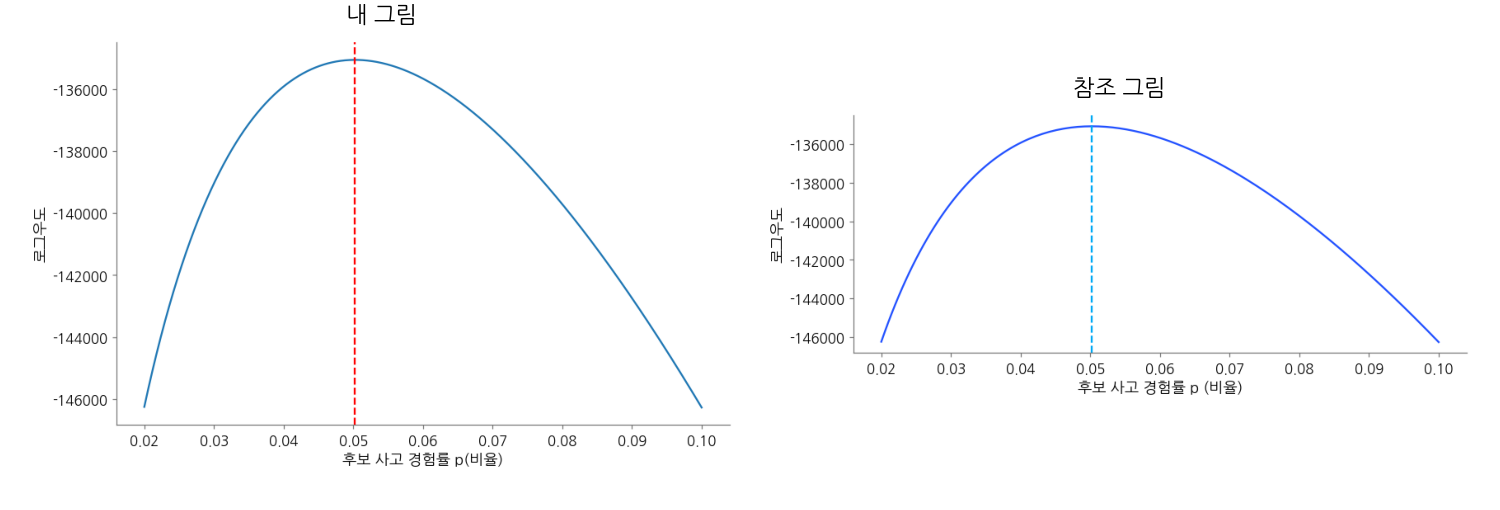

In [3]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """계약 전체의 사고 경험률을 구할거야 [df] 안에 y는 계약별 사고 유무 (0/1) n_all은 전체 계약 수(단위 건)
bern_nll(p)는 p를 받아 음의 로그우도를 돌려주는 함수야 나는 아래의 항목이 모두 추출되도록 코드를 작성할건데 [사고 경험률]은 단위는 비율, 소수 여섯자리까지 나오고 bern_nll을 수치 최적화로 가장 작게 만드는 p고 [사고를 겪은 계약 수]는 단위 건, 정수, y를 전부 더한 값이야
그리고 공식으로 바로 구하는 해(closed-form)/k/n 수렴 여부, 반복 횟수를 행에 덧붙일건데 채점이 보는 값이 아니고 통과 뒤에 열리는 완성본과의 재조할 자리로 덧붙일거야
그리고나서 그래프도 한장 추가해줘 가로축은 [후보 사고 경험률] p0.02~0.10으로 세로축은 로그우도인 선 그래프로 곡선은 후보 p를 촘촘히 늘어놓은 로그우도 곡선 하나이고 수직선은 1번에서 찾은 p 자리 하나, 가로축 이름은 [후보 사고 경험률 p(비율], 세로축 이름은 [로그우도]로 설정해서 그래프 만들어줘
"""
#--- 여기부터 AI 코드 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

k = int(y.sum())

res = minimize_scalar(bern_nll, bounds=(1e-6, 1 - 1e-6), method="bounded")
p_hat = round(res.x, 6)
p_closed = round(k / n_all, 6)

result_df = pd.DataFrame([{
    "사고 경험률": p_hat,
    "사고를 겪은 계약 수": k,
    "closed_form_p": p_closed,
    "k/n": p_closed,
    "converged": res.success,
    "iterations": res.nfev,
}])
print(result_df)

p_grid = np.linspace(0.02, 0.10, 2000)
loglik = [-bern_nll(p) for p in p_grid]

plt.figure(figsize=(8, 5))
plt.plot(p_grid, loglik)
plt.axvline(p_hat, color="red", linestyle="--")
plt.xlabel("후보 사고 경험률 p(비율)")
plt.ylabel("로그우도")
plt.show()

> **[문제] 미션 1 의 「여기부터 AI 코드」 행 아래 코드에서 `minimize` 에 넘긴 목적함수가 `bern_nll` 인 것이 결과에 어떻게 작용하나요?**
>
> 1. 로그우도를 그대로 넘긴 것과 같아, 최적화가 최댓값 지점을 향해 올라간다
> 2. 부호를 뒤집어 최솟값을 찾게 만든 것이라, 찾은 p 는 로그우도가 최대가 되는 p 와 같다
> 3. 부호를 뒤집었으므로 찾은 p 도 뒤집혀, 로그우도 최대 지점과는 다른 값이 나온다

## 표준오차가 0 으로 찍힌 세그먼트는 정말 가장 확실한가

### 미션 2 — 세그먼트마다 ±2SE 를 재고 계약 수가 적은 세그먼트를 구분한다 (함정 미션)

#### 할 일 — 미션 2 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 「PROMPT 셀」을 **먼저 그대로 ▶** 해 전임 담당자 코드의 채점 결과(❌)를 봅니다.
3. 아래 고칠 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
4. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
5. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 4번부터 다시 합니다.

**이 미션의 질문** — 계약 수가 적은 세그먼트 가운데 ±2SE 가 0 으로 찍힌 곳이 정말 가장 확실한 곳입니까?

**±2SE** 는 표준오차 × 2, 곧 구간 한쪽 길이입니다. 구간 전체가 아니라 이 숫자를 찍습니다.

#### 고치기 전에 — 어디가 틀렸는지 먼저 찾아보세요

「여기부터 AI 코드」 아래를 한 행씩 읽고, 사고가 0건인 세그먼트를 ±2SE 공식에 손으로 넣어 보세요.

> **[예측] 「여기부터 AI 코드」 행 아래 코드는 오류 없이 돌아가는데 답이 틀렸습니다. 틀린 곳은 어디일까요?**
>
> 1. ±2SE 공식의 분모가 계약 수 n 이 아니라 n − 1 이다
> 2. 사고가 0건인 세그먼트에서 ±2SE 가 0 으로 나오는데, 그 0 을 「추정값이 안정되었다」로 읽어 순위 맨 앞에 뒀다
> 3. 2 를 곱하지 않아 ±2SE 가 절반으로 나온다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

찾은 자리에 근거를 한 문장 적고, 몇 개 세그먼트가 순위에서 빠질지도 적어 두세요.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `seg3` | 세그먼트 2,323행 표, 열은 `n` · `k` · `c` · `p_mle` | 고정 |
| `p_all` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 — 이번 미션에서는 쓰지 않고 과제에서 판정 기준값으로 씁니다 | 고정 |

#### 고칠 것

「여기부터 AI 코드」 행 아래에 전임 담당자 코드가 이미 들어 있습니다. 오류 없이 돌아가는데 값이 틀렸고 그림이 없어요. 고친 뒤의 아래 넷이 이 미션에서 만들 것입니다.

1. **계약 40건 세그먼트의 ±2SE** — 단위 비율 · 소수 여섯 자리
   - 지금 : ±2SE 가 좁은 순서로 정렬한 뒤 맨 앞 행의 값을 찍습니다
   - 고친 뒤 : 이론 3절 퀴즈에서 손으로 ±2SE 를 재 본 그 세그먼트(계약 40건 · 사고 3건)를 `n` 과 `k` 로 직접 골라 그 행의 ±2SE 를 찍습니다
2. **±2SE 를 계산할 수 없는 세그먼트 수** — 단위 개 · 정수
   - 지금 : `isna()` 로 세어 0 개가 나옵니다
   - 고친 뒤 : 결측이 아니라 다른 조건으로 직접 셉니다
3. **그래프 한 장** — 가로축은 세그먼트의 계약 수, 세로축은 그 세그먼트의 사고 경험률인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 2,323개
   - 가로축 눈금 : 로그 눈금 — 눈금 한 단계가 10배씩 벌어집니다. matplotlib 에서는 `set_xscale` 한 행이에요
   - 가로축 이름 : 「세그먼트의 계약 수 (건, 로그 눈금)」
   - 세로축 이름 : 「사고 경험률 (비율)」
   - 지금 : 그림이 없습니다. 같은 프롬프트에서 새로 시켜야 나옵니다
4. **남길 다섯 행** — ±2SE 가 좁은 순서로 다섯 세그먼트를 그대로 남겨 둡니다
   - 채점이 보는 값은 아니고, 고치기 전과 뒤에 어떤 세그먼트가 앞자리에 오는지 볼 자리예요

<img src="https://en.wikipedia.org/wiki/Special:FilePath/FloreAndWicherts2015_meta_analysis_sex_stereotype_threat.png" width="480" height="449"/>
<p align="center"><em>▲ 고칠 것 3번 — 깔때기 그림(funnel plot). 가로축이 추정값, 세로축이 표준오차이고 아래로 갈수록 표본이 작아 좌우로 넓게 흩어진다. 우리 산점도는 이것을 90° 돌려 본 것이라 계약이 적은 왼쪽에서 세로로 벌어진다 — 계약 1건 세그먼트는 0 과 1 양 끝에, 18,042건 세그먼트는 한 자리에 모인다 (출처: Wikimedia Commons, Flore &amp; Wicherts 2015 funnel plot)</em></p>

**통과 기준** — 값 둘이 「이름 = 값 단위」 꼴로 한 행씩 찍히고, 산점도 한 장이 위 요구를 다 갖추면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고칠 자리** — 어느 값을 어떤 조건으로 다시 고를지, 세는 법을 무엇으로 바꿀지.
- **손대지 말 범위** — `seg3` 는 이미 있으니 표를 다시 만들지 말고 `n` · `k` · `c` · `p_mle` 열을 그대로 쓰라고 적습니다.
- **출력** — 값 두 개의 이름과 단위, 그리고 소수 몇 자리까지 찍을지.
- **그래프** — 가로축·세로축에 무엇을 놓을지 · 가로축 눈금 · 이름을 다는 것.

**막히면** — AI 튜터에게 「사고가 한 건도 없는 세그먼트에 ±2SE 공식을 넣으면 어떤 값이 나오나요」 처럼 물어보세요.

<details class="lms-extra"><summary>배경 — 이론 3절의 ±2SE 를 세그먼트 2,323개에 적용하는 자리</summary>

미션 1 에서 계약 678,013건을 한 덩어리로 놓고 사고 경험률 한 숫자를 얻었죠. 요율표는 그 한 숫자로 끝나지 않습니다. 지역·차종·마력이 다른 세그먼트마다 값을 따로 적어야 하고, 세그먼트의 계약 수가 적을수록 그 값이 표본에 따라 얼마나 달라지는지도 같이 적어야 해요.

이론 3절에서 **±2SE 구간**(추정값 ± 표준오차의 2배)을 「표본에 따라 추정값이 달라지는 범위」로 정의했고, 계약이 줄면 그 구간이 벌어지는 것도 보았죠. 위에서 「±2SE」라고 적는 숫자는 그 ± 뒤에 붙는 값, 곧 구간 한쪽의 길이입니다. ±2SE 가 좁은 세그먼트일수록 요율표에 그대로 옮겨 적기 좋은 세그먼트이니, 좁은 순서로 순위를 매기는 것이 전임 담당자의 계획이었어요.

**±2SE 를 계산할 수 없는 세그먼트**는 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트입니다. 값은 0 으로 멀쩡히 나오지만 그 0 은 표본에 따른 차이를 잰 값이 아니라서, 순위에 올리지 않고 판정에서 제외합니다.

**로그 눈금(log scale)** 은 눈금 한 단계가 10배씩 벌어지는 눈금입니다. 세그먼트마다 계약 수가 1건부터 18,042건까지 섞여 있어, 보통 눈금에서는 점이 왼쪽 끝에 뭉쳐 모양이 안 보이거든요. matplotlib 에서는 `ax.set_xscale("log")` 한 행입니다.

</details>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Confidence_interval.png" width="600" height="478"/>
<p align="center"><em>▲ 같은 모집단에서 표본을 여러 번 뽑아 그때마다 95% 구간을 그린 그림 — 막대 13개 가운데 맨 위 막대 하나가 참값 세로선을 비껴가듯, ±2SE 구간은 추정값이 표본에 따라 달라지는 범위이지 참값을 보증하는 표가 아니다 (출처: ultrabem.com via Wikimedia Commons, Confidence interval.png)</em></p>

위 신뢰구간 그림에서 — 세로선이 우리가 끝내 모르는 참값이고, 가로 막대 하나가 표본 하나의 95% 구간입니다. 막대의 길이가 표본마다 다른 것처럼, 세그먼트마다 계약 수가 달라 ±2SE 구간의 길이도 달라집니다.

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 미션만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 오늘 고정한 전처리 두 규칙 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)              # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 지역 x 차종 x 마력으로 가른 세그먼트 표. 한 행이 요율표의 세그먼트 하나입니다
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건, 오늘은 쓰지 않습니다)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약(회사 전체)의 사고 경험률 (비율)


def _2se(k, n):                            # 이론 3절의 ±2SE — 표준오차 x 2
    p = k / n
    return 2 * (p * (1 - p) / n) ** 0.5


_c63 = (seg3[(seg3["n"] == 63) & (seg3["k"] == 4)]
        .sort_values(["Region", "VehBrand", "VehPower"]).iloc[0])
_r43 = df.loc[df["Region"] == "R43", "HasClaim"]

print(f"세그먼트 수 : {len(seg3):,} 개 | 계약 합 : {int(seg3['n'].sum()):,} 건"
      f" | 사고를 겪은 계약 합 : {int(seg3['k'].sum()):,} 건")
print(f"세그먼트의 계약 수 — 가장 적은 세그먼트 {int(seg3['n'].min()):,} 건 ·"
      f" 가운데 {int(seg3['n'].median()):,} 건 · 가장 많은 세그먼트 {int(seg3['n'].max()):,} 건")
print("\n이론 3절에서 본 세 행 — 계약이 줄면 ±2SE 가 어떻게 벌어지는가")
for name, k, n in [("전체 계약", int(df["HasClaim"].sum()), len(df)),
                  ("지역 R43", int(_r43.sum()), int(_r43.size)),
                  ("계약 63건 세그먼트", int(_c63["k"]), int(_c63["n"]))]:
    print(f"  {name} : 계약 {n:,}건 · 사고 경험률 {k / n:.6f} · ±2SE {_2se(k, n):.6f}")
print("\n쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)")

세그먼트 수 : 2,323 개 | 계약 합 : 678,013 건 | 사고를 겪은 계약 합 : 34,060 건
세그먼트의 계약 수 — 가장 적은 세그먼트 1 건 · 가운데 41 건 · 가장 많은 세그먼트 18,042 건

이론 3절에서 본 세 행 — 계약이 줄면 ±2SE 가 어떻게 벌어지는가
  전체 계약 : 계약 678,013건 · 사고 경험률 0.050235 · ±2SE 0.000531
  지역 R43 : 계약 1,326건 · 사고 경험률 0.040724 · ±2SE 0.010856
  계약 63건 세그먼트 : 계약 63건 · 사고 경험률 0.063492 · ±2SE 0.061443

쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)


계약 40건 세그먼트의 ±2SE = 0.083292 비율
±2SE 를 계산할 수 없는 세그먼트 수 = 759 개
Region VehBrand  VehPower  n  k  p_mle  표준오차
   R42      B11         9  1  0    0.0       0.0
   R25      B14         4 14  0    0.0       0.0
   R25      B14         5  4  0    0.0       0.0
   R25      B14         6 17  0    0.0       0.0
   R25      B14         8  6  0    0.0       0.0

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ 계약 40건 세그먼트의 ±2SE (비율) — 출력에서 0.083292 를 찾았습니다
✅ ±2SE 를 계산할 수 없는 세그먼트 수 (개) — 출력에서 759 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 미션 2 완성본 — 고칠 곳은 「여기부터 AI 코드」 행 아래 딱 한 행입니다

■ 이 코드를 부른 프롬프트 예

    아래 코드에서 ±2SE 를 세는 행이 사고가 0건인 세그먼트에도 0 을 돌려주는 게 문제야. 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트는
    ±2SE 를 계산할 수 없는 세그먼트로 따로 세고 순위에서 빼 줘. 이미 만들어져 있는 seg3 와 p_all 을 그대로 쓰고 표를 다시 만들지는 말아 줘.
    계약 40건·사고 3건 세그먼트는 n 과 k 로 직접 골라서 그 세그먼트의 ±2SE 를 "계약 40건 세그먼트의 ±2SE = (숫자) 비율" 처럼 소수 여섯
    자리까지 print 하고, ±2SE 를 계산할 수 없는 세그먼트가 몇 개인지도 "±2SE 를 계산할 수 없는 세그먼트 수 = (숫자)

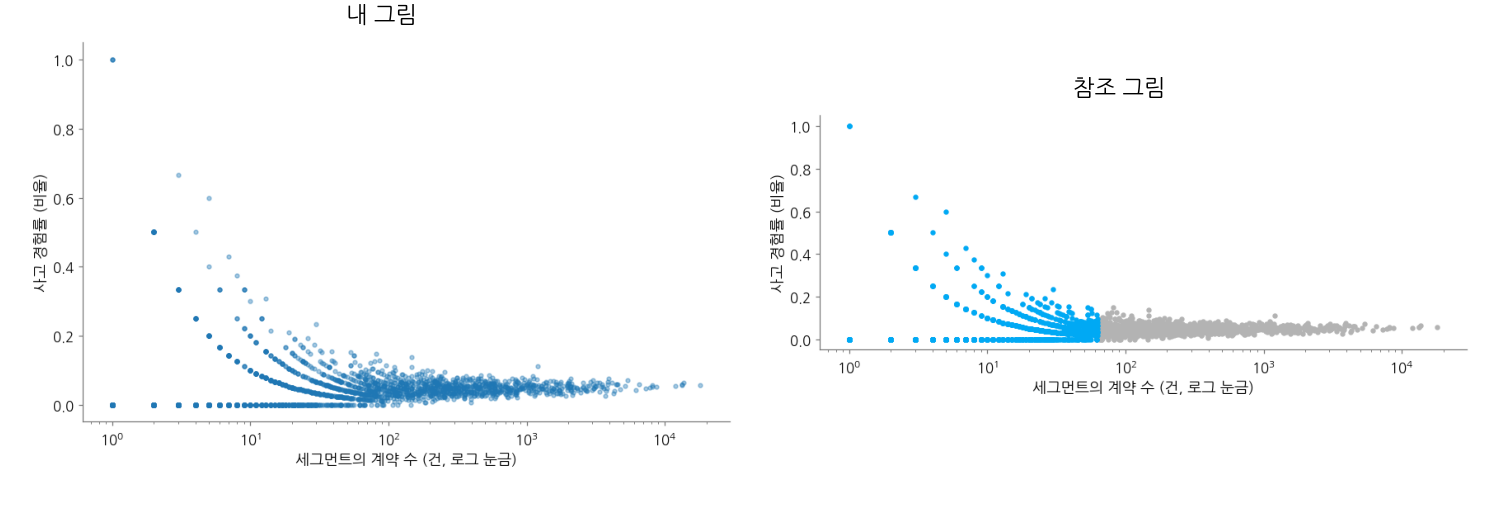

In [9]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 도우미가 구분선 아래를 다시 씁니다.
PROMPT = """
아래에 작성된 전임 담장자의 코드를 수정하려고 해
계약 40건 n = 40, k=3 기준으로 수정된 표준오차 ±2SE를 구할건데 단위는 비율, 소수 여섯 자리까지 허용
그 기준으로 ±2SE 를 계산할 수 없는 세그먼트 수를 계산하는(p_mle 가 0 또는 1 인 세그먼트 수를 센다) 코드도 넣어주고
마지막으론 그래프를 만들거야
가로축은 세그먼트의 계약수, 세로축은 그 세그먼트의 사고 경험률인 산점도
점은 세그먼트 하나에 점 하나, 즉 모두 2323개
가로축 눈금은 로그 눈금이고 한 단계가 10배씩 벌어지도록
가로축 이름은 [세그먼트의 계약 수 (건, 로그 눈금)]
세로축 이름은 [사고 경험률 (비율)]

마지막으로 다시 계산된 표준오차를 기준으로 좁은 순서로 다섯 세그먼트를 남겨서 행을 만들거야
채점이 보는 값은 아니고, 고치기 전과 뒤에 어떤 세그먼트가 앞자리에 오는지 볼 자리야.
"""
# --- 여기부터 AI 코드 ---
seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])

target = seg3[(seg3["n"] == 40) & (seg3["k"] == 3)]
se_40 = round(target["표준오차"].iloc[0], 6)
print(f"계약 40건 세그먼트의 ±2SE = {se_40:.6f} 비율")

n_undefined = int(((seg3["p_mle"] == 0) | (seg3["p_mle"] == 1)).sum())
print(f"±2SE 를 계산할 수 없는 세그먼트 수 = {n_undefined} 개")

plt.figure(figsize=(8, 5))
plt.scatter(seg3["n"], seg3["p_mle"], s=10, alpha=0.4)
plt.xscale("log")
plt.xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
plt.ylabel("사고 경험률 (비율)")
plt.show()

narrow_se_first = seg3.sort_values("표준오차")
print(narrow_se_first.head(5)[["Region", "VehBrand", "VehPower", "n", "k", "p_mle", "표준오차"]].to_string(index=False))

> **[문제] 미션 2 의 전임 담당자 코드에서 `seg3["표준오차"].isna().sum()` 이 0 을 돌려준 이유로 맞는 것은?**
>
> 1. `n` 이 0 인 세그먼트가 없어 나눗셈이 한 번도 실패하지 않았고, 사고가 0건인 세그먼트의 ±2SE 는 결측으로 남았다
> 2. 사고가 0건인 세그먼트도 제곱근 안이 0 이라 ±2SE 가 0 으로 멀쩡히 계산되어, 결측이 된 세그먼트가 한 곳도 없다
> 3. `isna()` 는 실수 열에서 언제나 0 을 돌려주므로, 결측이 있어도 세지 못한다

## 2등이 불가능하지 않다는 것을 자로 잴 수 있을까

### 미션 3 — 계약 수가 적은 세그먼트에 적어도 되는 값의 범위를 상대우도로 구한다

#### 할 일 — 미션 3 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문** — 계약 63건·사고 4건 세그먼트에 요율로 적어도 되는 값은 어디까지입니까?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `seg3` | 세그먼트 2,323행 표, 열은 `n` · `k` · `c` · `p_mle` — 이번 미션에서 직접 쓰는 것은 아래 `C63` · `CBIG` 두 행입니다 | 고정 |
| `C63` | 계약 63건·사고 4건 세그먼트 한 행 | 고정 |
| `CBIG` | 계약 수가 가장 많은 세그먼트 한 행 | 고정 |
| `p_all` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 | 고정 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **63건 세그먼트 상대우도 구간의 상한** — 단위 비율 · 소수 여섯 자리
   - 상대우도가 임계값 0.147 이상인 후보 가운데 가장 큰 값입니다
   - 상대우도 = 그 후보의 우도 ÷ 그 세그먼트 최댓값의 우도 · 임계값 0.147 = exp(−1.92), 곧 최댓값 우도의 약 15%
2. **전체 계약 사고 경험률의 상대우도** — 단위 비율 · 소수 여섯 자리
   - 63건 세그먼트 곡선에서 가로축이 `p_all` 인 한 점의 높이입니다
3. **덧붙일 한 행** — 두 세그먼트의 구간 길이를 나란히 찍어 몇 배 차인지 봅니다
   - 채점이 보는 값은 아니고, 통과 뒤 열리는 완성본과 대조할 자리예요
4. **그래프 한 장** — 가로축은 후보 사고 경험률 0.001 ～ 0.30, 세로축은 상대우도인 선 그래프
   - 곡선 : 둘. `C63` 세그먼트 하나, `CBIG` 세그먼트 하나
   - 수직선 : `C63` 세그먼트의 사고 경험률 자리에 하나 — `axvline` 로 긋습니다
   - 가로선 : 임계값 0.147 자리에 하나 — `axhline` 로 긋습니다. 점을 늘어놓아 그으면 곡선 하나로 세어집니다
   - 가로축 이름 : 「후보 사고 경험률 (비율)」
   - 세로축 이름 : 「상대우도」
   - 곡선 둘을 구분하는 범례도 답니다
   - 후보 격자 : 격자점 1,000개 이상으로 촘촘히 놓습니다. 구간의 양 끝값이 격자 간격만큼 달라지거든요

**출력 형식** — 「이름 = 값 단위」 꼴로 한 행씩 `print` 합니다. 그래프는 한 장입니다. 값은 소수 여섯 자리로 찍되, 보고서에 옮겨 적을 때는 셋째 자리까지만 말합니다 — 구간의 양 끝값은 격자 간격만큼 달라지거든요.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `seg3` · `C63` · `CBIG` · `p_all` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **상대우도를 구하는 법** — 두 세그먼트의 `n` 과 `k` 로 후보마다 로그우도를 재고, 그 세그먼트 최댓값과 견준다는 것.
- **출력** — 값 두 개의 이름과 단위, 그리고 소수 몇 자리까지 찍을지.
- **그래프** — 가로축 범위와 격자점 수 · 곡선 둘 · 수직선과 가로선의 자리 · 가로축·세로축 이름과 범례.

**막히면** — AI 튜터에게 「상대우도 곡선에서 구간의 양 끝을 어떻게 골라내나요」 처럼 물어보세요.

#### 재기 전에 — 어느 쪽일지 골라 보세요

회사 전체 값을 63건 세그먼트에 그대로 옮겨 적는다면, 그 세그먼트의 기록은 그 값을 얼마나 그럴듯하다고 볼까요.

> **[예측] 계약 63건·사고 4건 세그먼트에서 전체 계약의 사고 경험률 0.050235 의 상대우도는 얼마쯤일까요?**
>
> 1. 1000분의 1 아래 — 그 세그먼트의 값으로는 사실상 불가능하다
> 2. 10분의 1 근처 — 그럴듯한 쪽과는 거리가 있다
> 3. 최댓값의 9할 근처 — 그 세그먼트의 최댓값과 거의 대등하다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 이유를 한 문장 적고, 계약 수가 가장 많은 세그먼트에서는 같은 값이 어느 쪽에 설지도 함께 적어 두세요.

<details class="lms-extra"><summary>배경 — 미션 2 의 ±2SE 가 남긴 문제와 이론 4절의 상대우도</summary>

미션 2 의 준비 셀이 찍어 준 세 행 가운데 계약 63건 세그먼트 — 그 ±2SE 가 0.061443 이었죠. 그 세그먼트의 사고 경험률 0.063492 와 거의 같은 크기라, ±2SE 를 좌우로 그대로 뻗으면 아래쪽 끝이 0.002 까지 내려갑니다. ±2SE 구간은 최댓값 지점을 가운데 두고 좌우를 같은 길이로 자르는 구간입니다. 그래서 사고 경험률이 0 아래로 내려갈 수 없다는 것도, 왼쪽이 오른쪽보다 가파르다는 것도 반영하지 못해요.

이론 4절에서 **상대우도**를 「그 후보의 우도를 최댓값의 우도로 나눈 값」으로 정의하고, 그 값이 최댓값의 약 15%($e^{-1.92} = 0.147$) 이상인 후보를 모아 그럴듯한 범위로 불렀죠. 3번 던져 3번 앞면과 30번 던져 30번 앞면의 구간 길이가 0.47 대 0.06 으로 갈리던 그림이 그 자리였고요. 오늘은 같은 방법을 동전이 아니라 요율표 세그먼트 두 곳에 적용합니다.

</details>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/LikelihoodFunctionAfterHHT.png" width="600" height="450"/>
<p align="center"><em>▲ 동전을 세 번 던져 앞·앞·뒤가 나온 뒤의 우도 곡선(가로축 앞면 확률 후보 P_H, 세로축 우도) — 최댓값은 2/3 자리(우도 0.148)이지만 좌우가 완만해, 상대우도로 재면 0.4 는 최댓값의 0.65배 · 0.9 는 0.55배로 둘 다 임계값 0.147 위에 남는다 (출처: Wikimedia Commons, Stephen.scott.webb, public domain)</em></p>

관측이 세 번뿐이라 곡선이 완만하고, 계약 63건 세그먼트의 곡선도 같은 사정입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Negative_and_positive_skew_diagrams_(English).svg" width="640" height="228"/>
<p align="center"><em>▲ 최댓값 지점은 같아도 꼬리가 한쪽으로 늘어진 두 분포 — 계약 63건 세그먼트는 오른쪽 패널 모양이라, 우도로 다시 재면 최댓값 0.063492 를 두고 왼쪽과 오른쪽이 다른 길이로 갈린다 (출처: Wikipedia)</em></p>

<details class="lms-extra"><summary>자세히 — 위 그림의 붉은 실선과 회색 점선</summary>

회색 점선이 좌우가 같은 대칭 곡선이고, 붉은 실선이 실제 모양입니다. 왼쪽 패널은 꼬리가 왼쪽으로 뻗은 음의 왜도, 오른쪽 패널은 오른쪽으로 뻗은 양의 왜도입니다.

</details>

In [5]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 미션만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)      # 오늘 고정한 전처리 두 규칙 — 미션 1·2 와 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)             # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 세그먼트 표를 미션 2 와 같은 규칙으로 다시 셉니다 (앞에서 덧붙인 열은 남기지 않습니다)
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건, 오늘은 쓰지 않습니다)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약의 사고 경험률 (비율)

# 쓸 변수 3 — 계약 63건·사고 4건 세그먼트 한 행. 같은 조건의 세그먼트가 둘이라 이름 순서로 하나를 고정합니다
C63 = (seg3[(seg3["n"] == 63) & (seg3["k"] == 4)]
       .sort_values(["Region", "VehBrand", "VehPower"]).iloc[0])
# 쓸 변수 4 — 계약 수가 가장 많은 세그먼트 한 행
CBIG = seg3.sort_values("n", ascending=False).iloc[0]

for name, seg_row in [("계약 63건 세그먼트", C63), ("계약 수가 가장 많은 세그먼트", CBIG)]:
    print(f"{name} : {seg_row['Region']} x {seg_row['VehBrand']} x {int(seg_row['VehPower'])}마력"
          f" | 계약 {int(seg_row['n']):,}건 · 사고를 겪은 계약 {int(seg_row['k']):,}건"
          f" · 사고 경험률 {seg_row['p_mle']:.6f} (비율)")
print(f"전체 계약의 사고 경험률 : {p_all:.6f} 비율 — 두 세그먼트 모두 이 값이"
      " 그 세그먼트의 값으로도 그럴듯한지 재 볼 자리입니다")
print(f"이론 4절의 임계값 : exp(-1.92) = {np.exp(-1.92):.6f} — 상대우도가 이 값 이상인"
      " 후보만 구간에 포함됩니다")
print("\n쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · C63 (계약 63건·사고 4건 세그먼트 한 행)"
      " · CBIG (계약 수가 가장 많은 세그먼트 한 행) · p_all (전체 계약의 사고 경험률, 비율)")

계약 63건 세그먼트 : R22 x B3 x 4마력 | 계약 63건 · 사고를 겪은 계약 4건 · 사고 경험률 0.063492 (비율)
계약 수가 가장 많은 세그먼트 : R24 x B1 x 6마력 | 계약 18,042건 · 사고를 겪은 계약 1,023건 · 사고 경험률 0.056701 (비율)
전체 계약의 사고 경험률 : 0.050235 비율 — 두 세그먼트 모두 이 값이 그 세그먼트의 값으로도 그럴듯한지 재 볼 자리입니다
이론 4절의 임계값 : exp(-1.92) = 0.146607 — 상대우도가 이 값 이상인 후보만 구간에 포함됩니다

쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · C63 (계약 63건·사고 4건 세그먼트 한 행) · CBIG (계약 수가 가장 많은 세그먼트 한 행) · p_all (전체 계약의 사고 경험률, 비율)


63건 세그먼트 상대우도 구간 상한 = 0.141152 비율
전체 계약 사고 경험률의 상대우도 = 0.898101 비율
C63 구간 길이 = 0.120856, CBIG 구간 길이 = 0.006581, 배수 = 18.36배

──────────────────────────────────────────────────────
◼ 미션 3 채점 결과
✅ 63건 세그먼트 상대우도 구간의 상한 (비율) — 출력에서 0.141152 를 찾았습니다
✅ 전체 계약 사고 경험률의 상대우도 (비율) — 출력에서 0.898101 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 미션 3 완성본 — 「여기부터 AI 코드」 행 아래에 들어올 코드는 이 정도입니다

■ 이 코드를 부른 프롬프트 예

    이미 만들어져 있는 seg3, C63, CBIG, p_all 을 그대로 쓰고 다시 만들지는 말아 줘. 후보 사고 경험률을 0.001 부터 0.30 까지 격자점
    2,001개로 촘촘히 늘어놓고, C63 과 CBIG 두 세그먼트에서 후보마다 상대우도(그 후보의 우도를 그 세그먼트 최댓값의 우도로 나눈 값)를
    계산해 줘. 상대우도가 exp(-1.92) 이상인 후보만 남겨 C63 쪽 구간의 위쪽 끝을 "63건 세그먼트 상대우도 구간의 상한 = (숫자) 비율" 처럼
    소수 여섯 자리까지 print 하고, C63 에서 p_all 자리의 상대우도도 "전체 계약 사고 경험률의 상대우도 = (숫자) 비율" 로 한 행 더 print
    해 줘. 그래프는 딱 한 장만 그려 줘 — 가로축은 후보 사고 경험률, 세로축은 상대우도로 두 세그먼트의 곡선을 각각 하나씩 그리고,
    C63 의 사고 경험률 자리에 수직선을 하나, exp(-1.92) 높이에 가로선을 하나 얹은 뒤 두 축에 라벨과 범례를 달아 줘.

    cands = np.linspace(0.001, 0.30, 2001)         

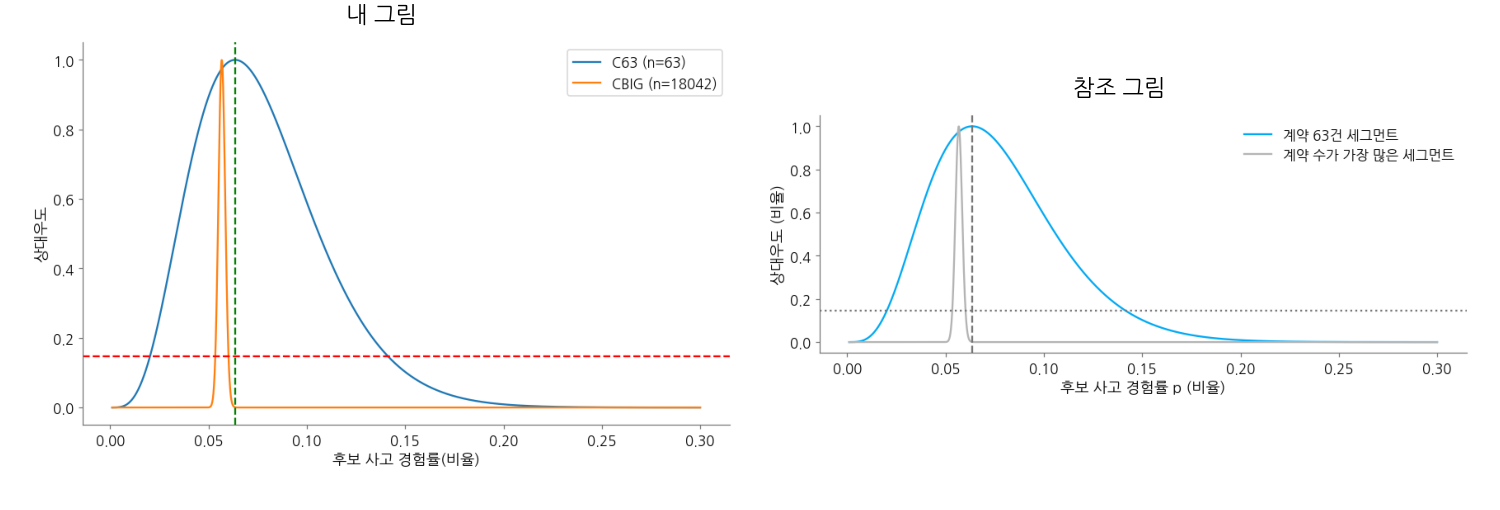

In [6]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
1. 63건 세그먼트 상대우도 구간의 상한 / 단위: 비율, 소수 여섯 자리까지
상대우도가 임계값 0.147 이상인 후보 가운데 가장 큰 값임.
상대우도 = 그 후보의 우도 / 그 세그먼트 최댓ㄱ밧의 우도, 임계값 0.147 = exp(-1.92), 곧 최대값 우도의 약 15%임

2. 전체 계약 사고 경험률의 상대우도 / 단위: 비율, 소수 여섯 자리까지
63건 세그먼트 곡선에서 가로축이 p_all인 한 점의 높이

3. 덧붙일 한 행
두 세그먼트의 구간 길이를 나란히 찍어 볓 배 차이인지 볼 용도
채점이 보는 값이 아니고, 통과 뒤에 열리는 완성본과 대조할 자리임.

4. 그래프 한장 가로축은 후보 사고 경험률 0.001 ~ 0.30, 세로축은 상대우도인 선 그래프임.
곡선: 둘, C63 세그먼트 하나, CBIG 세그먼트 하나
수직선: C63 세그먼트의 사고 경험률 자리에 하나
가로선: 임계값 0.147 자리에 하나
가로축 이름: [후보 사고 경험률(비율)]
세로축 이름: [상대우도]
곡선 둘을 구분하는 범례 달기
후보 격자: 격자점 1,000개 이상으로 촘촘히

출력 형식은 [이름 = 값 단위] 꼴로 한 행씩 print하고 그래프 한장


"""
# --- 여기부터 AI 코드 ---
n63, k63 = C63["n"], C63["k"]
nbig, kbig = CBIG["n"], CBIG["k"]
p63_hat = k63 / n63
pbig_hat = kbig / nbig

def loglik(p, k, n):
    return k * np.log(p) + (n - k) * np.log(1 - p)

def rel_lik(p, k, n, p_hat):
    return np.exp(loglik(p, k, n) - loglik(p_hat, k, n))

threshold = 0.147
p_grid = np.linspace(0.001, 0.30, 2000)

R63 = rel_lik(p_grid, k63, n63, p63_hat)
Rbig = rel_lik(p_grid, kbig, nbig, pbig_hat)

mask63 = R63 >= threshold
upper63 = p_grid[mask63].max()
lower63 = p_grid[mask63].min()

maskbig = Rbig >= threshold
upperbig = p_grid[maskbig].max()
lowerbig = p_grid[maskbig].min()

len63 = upper63 - lower63
lenbig = upperbig - lowerbig
ratio = len63 / lenbig

rel_at_p_all = rel_lik(p_all, k63, n63, p63_hat)

print(f"63건 세그먼트 상대우도 구간 상한 = {upper63:.6f} 비율")
print(f"전체 계약 사고 경험률의 상대우도 = {rel_at_p_all:.6f} 비율")
print(f"C63 구간 길이 = {len63:.6f}, CBIG 구간 길이 = {lenbig:.6f}, 배수 = {ratio:.2f}배")

plt.figure(figsize=(8, 5))
plt.plot(p_grid, R63, label=f"C63 (n={n63})")
plt.plot(p_grid, Rbig, label=f"CBIG (n={nbig})")
plt.axvline(p63_hat, color="green", linestyle="--")
plt.axhline(threshold, color="red", linestyle="--")
plt.xlabel("후보 사고 경험률(비율)")
plt.ylabel("상대우도")
plt.legend()
plt.show()

> **[문제] 미션 3 에서 상대우도를 잴 때, 후보마다의 로그우도에서 그 세그먼트 최댓값의 로그우도를 빼고 `np.exp` 를 씌우는 것은 무엇을 하는 계산인가요?**
>
> 1. 로그우도를 그 후보가 맞을 확률로 바꾼다
> 2. 임계값 0.147 을 곱해 구간의 양 끝을 잘라 낸다
> 3. 그 후보의 우도를 최댓값의 우도로 나눈 것과 같아, 곡선의 가장 높은 자리를 1 로 맞춘다

## 요율표의 어느 세그먼트까지 이 숫자를 그대로 적어도 되나

> **[과제] 과제 제출 — 요율표 2,323개 세그먼트에 판정 붙이기**
>
> - **무엇을** 세그먼트마다 판정이 적힌 표 한 장과 사람이 다시 볼 계약 수 한 행을 만듭니다.
> - **무엇으로** 오늘 내내 쓴 그 계약 기록 하나로 하고, 준비 셀이 2,323개 세그먼트 집계까지 만들어 둡니다.
> - **인정** 채점이 값 넷과 그림을 통과시킨 노트북에 브리핑 세 문장과 답신을 붙인 것입니다.
> - **예** 계약 3건·사고 2건인 세그먼트는 ±2SE 가 0.544 라 기준값 0.050235 보다 넓어 판정이 「재검토」 로 붙고, 값 행은 「그대로 사용 세그먼트 수 = ○○○ 개」 꼴 한 행입니다.
> 
> - 「PROMPT 셀」을 실행해 값 넷과 그림 한 장을 모두 통과시킵니다.
> - 그 셀의 PROMPT 는 지우지 말고 내가 쓴 그대로 둡니다.
> - 판정 세 가지를 적은 열을 세그먼트 표에 남깁니다.
> - 브리핑 세 문장을 이 절 끝 양식에 채웁니다.
> - 상품팀 답신 세 문장을 그 아래 양식에 채웁니다.
>
> 마감: 2026-09-29T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 문제 정의 | 「PROMPT 셀」의 PROMPT 에 판정 규칙 셋이 내 말로 적혀 있다. | 25 |
> | 검증 설계 | 값 넷과 그림이 모두 채점을 통과했다. | 25 |
> | 오류 탐지 | ±2SE 를 계산할 수 없는 세그먼트를 먼저 제외한 근거를 브리핑에 서술했다. | 25 |
> | 해석·보고 | 답신이 세그먼트 수와 계약 수를 단위와 함께 제시한다. | 25 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 또는 Google Drive 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

### 과제 — 요율표 2,323개 세그먼트에 판정을 붙인다

#### 할 일 — 과제 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.
5. 이 절 끝 양식에 브리핑 세 문장과 상품팀 답신을 채워 제출합니다.

**이 과제의 질문** — 요율표 2,323개 세그먼트 가운데 어디를 그대로 쓰고 어디를 사람이 다시 봐야 합니까?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `df` | 계약 678,013행 표, 열은 `ClaimNb` · `HasClaim` | 고정 |
| `seg3` | 세그먼트 2,323행 표, 열은 `n` · `k` · `c` · `p_mle` | 고정 |
| `p_all` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 · 판정 기준값 | 고정 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **판정 열 하나** — 세그먼트마다 셋 중 하나를 적어 `seg3` 의 열로 남깁니다
   - 「계산 불가」 : 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트
   - 「재검토」 : 남은 세그먼트 중 ±2SE 가 `p_all` 보다 넓은 세그먼트
   - 「그대로 사용」 : 나머지 세그먼트
2. **그대로 사용 세그먼트 수** — 단위 개 · 정수
3. **재검토·계산 불가 세그먼트에 속한 계약 수** — 단위 건 · 정수
   - 세그먼트 수가 아니라 그 세그먼트들의 `n` 을 더한 값입니다
4. **재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수** — 단위 건 · 정수
5. **계약당 사고 건수** — 단위 건/계약 · 소수 여섯 자리
   - 이 값만 0/1 변수가 아닙니다. 사고 유무가 아니라 사고 건수 열의 평균이에요
6. **그래프 한 장** — 가로축은 세그먼트의 계약 수, 세로축은 그 세그먼트의 ±2SE 인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 2,323개
   - 가로축 눈금 : 로그 눈금
   - 색 : 판정 셋을 색으로 구분하고 범례를 답니다
   - 가로축 이름 : 「세그먼트의 계약 수 (건, 로그 눈금)」
   - 세로축 이름 : 「±2SE (비율)」

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Poisson_pmf.svg" width="520" height="403"/>
<p align="center"><em>▲ 만들 것 5번 — 사고 건수처럼 0, 1, 2 … 로 세는 값의 분포. 가로축이 건수 k, 세로축이 그 건수가 나올 확률이다. 평균이 1 이면 0건과 1건에 확률이 몰리고, 평균이 4 나 10 으로 커지면 최댓값 지점이 오른쪽으로 옮겨 간다. 계약당 사고 건수는 이 분포의 평균이고, 오늘의 0/1 변수와는 다른 숫자가 된다 (출처: Wikimedia Commons, Poisson pmf.svg)</em></p>

**출력 형식** — 값 넷을 「이름 = 값 단위」 꼴로 한 행씩 `print` 합니다. 그래프는 한 장이고, 표는 파일로 내보내지 않습니다.

#### 프롬프트에 넣을 것(힌트)

- **판정 순서** — 셋을 어떤 차례로 적용할지 적습니다. 순서가 빠지면 사고 0건 세그먼트가 ±2SE 0 을 달고 「그대로 사용」 쪽으로 넘어갑니다.
- **고정할 이름** — `df` · `seg3` · `p_all` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **출력** — 값 넷의 이름과 단위, 그리고 「계약당 사고 건수」를 소수 몇 자리까지 찍을지.
- **그래프** — 가로축·세로축에 무엇을 놓을지 · 가로축 눈금 · 색으로 구분할 것 · 이름과 범례.

**막히면** — AI 튜터에게 「판정 셋을 어떤 순서로 적용해야 계산 불가 세그먼트가 섞이지 않나요」 처럼 물어보세요.

#### 판정하기 전에 — 몇 할일지 골라 보세요

판정을 붙이기 전에, 2,323개 세그먼트 가운데 「그대로 사용」이 차지할 몫을 먼저 골라 두세요.

> **[예측] 요율표 2,323개 세그먼트 가운데 「그대로 사용」 판정을 받는 세그먼트는 몇 할쯤일까요?**
>
> 1. 1할 미만 — 계약이 적은 세그먼트가 대부분이라 거의 다 사람이 다시 본다
> 2. 4할 안팎 — 세그먼트 수로는 절반 가까이 갈린다
> 3. 8할 이상 — 계약 수가 넉넉한 세그먼트가 대부분이다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 이유를 한 문장 적고, 세그먼트 수가 아니라 계약 수로 세면 그 몫이 어느 쪽으로 움직일지도 적어 두세요.

<details class="lms-extra"><summary>배경 — 상품팀의 되물음과 판정 기준값이 회사 전체 값인 까닭</summary>

상품팀이 새 요율표 초안을 받아 갔다가 되물어 왔습니다 — **"세그먼트 2,323개에 숫자가 다 채워져 있는데, 어느 세그먼트를 그대로 쓰고 어느 세그먼트를 사람이 다시 봐야 하는지 표에 적어 주세요."** 미션 2 에서 ±2SE 를 계산할 수 없는 세그먼트 759개는 이미 구분했으니, 남은 세그먼트에 기준선을 하나 더 긋는 일입니다.

±2SE 가 회사 전체 값 자체보다 넓다면, 그 세그먼트의 숫자는 요율 단위 위에서 어느 값이라고 말할 수 없습니다. 이론 3절에서 계약 67만 8천 건의 ±2SE 를 두고 「요율을 5.0% 로 적을지 5.1% 로 적을지가 이 안에서 갈린다」로 읽었던 그 기준이에요. 세그먼트마다 제 값을 기준값으로 삼으면 측정 단위가 세그먼트마다 달라집니다.

계약 3건에 사고 2건인 세그먼트가 그 예예요. 그 세그먼트의 값은 0.667 이고 ±2SE 는 0.544 라, 제 값보다는 좁아 통과해 버립니다. 기준값 하나를 회사 전체 값으로 고정해야 2,323개 세그먼트를 같은 기준으로 평가합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Empirical_Rule.PNG" width="640" height="464"/>
<p align="center"><em>▲ 평균에서 좌우로 표준편차 두 개만큼 벌린 구간이 데이터의 95% 를 덮는다는 경험 규칙 — 표준편차 한 배 구간이 68%, 두 배 구간이 95%, 세 배 구간이 99.7% 다. ±2SE 구간을 판정 기준으로 쓰는 근거가 가운데 95% 이고, 과제는 그 구간을 회사 전체 값과 견줘 세그먼트를 구분한다 (출처: Wikimedia Commons, Empirical Rule.PNG)</em></p>

「계약당 사고 건수」만 측정 단위가 다릅니다. 오늘 내내 센 것은 「겪었는가」였고, 이 값은 「몇 건인가」예요. 이론 4절에서 포아송 MLE 가 표본평균으로 떨어진다고 본 그 값이라, 사고 건수 열의 평균을 그대로 찍으면 됩니다. 두 값이 얼마나 갈리는지는 통과 뒤 열리는 완성본에서 확인하세요.

</details>

In [7]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 절만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)      # 오늘 고정한 전처리 두 규칙 — 미션 1·2·3 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)             # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 세그먼트 표를 미션 2·3 과 같은 규칙으로 다시 셉니다 (앞에서 덧붙인 열은 남기지 않습니다)
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약의 사고 경험률 (비율) = 판정 기준값

unmeasurable_segs = int(((seg3["k"] == 0) | (seg3["k"] == seg3["n"])).sum())
print(f"세그먼트 {len(seg3):,}개 | 컬럼 {list(seg3.columns)}")
print(f"판정 기준값 — 전체 계약의 사고 경험률 p_all = {p_all:.6f} 비율")
print(f"±2SE 를 계산할 수 없는 세그먼트 = {unmeasurable_segs} 개 — 미션 2 에서 구분한 그 세그먼트들입니다")
print(f"세그먼트의 계약 수 : 가장 적은 세그먼트 {int(seg3['n'].min()):,}건"
      f" · 가운뎃값 {int(seg3['n'].median()):,}건"
      f" · 가장 많은 세그먼트 {int(seg3['n'].max()):,}건")
print(f"전체 계약 {int(seg3['n'].sum()):,}건 — 세그먼트의 계약 수를 모두 더한 값입니다")
print("\n쓸 수 있는 이름 : df (ClaimNb · HasClaim 열) · seg3 (n · k · c · p_mle 열)"
      " · p_all (전체 계약의 사고 경험률, 비율)")

세그먼트 2,323개 | 컬럼 ['Region', 'VehBrand', 'VehPower', 'n', 'k', 'c', 'p_mle']
판정 기준값 — 전체 계약의 사고 경험률 p_all = 0.050235 비율
±2SE 를 계산할 수 없는 세그먼트 = 759 개 — 미션 2 에서 구분한 그 세그먼트들입니다
세그먼트의 계약 수 : 가장 적은 세그먼트 1건 · 가운뎃값 41건 · 가장 많은 세그먼트 18,042건
전체 계약 678,013건 — 세그먼트의 계약 수를 모두 더한 값입니다

쓸 수 있는 이름 : df (ClaimNb · HasClaim 열) · seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)


그대로 사용 세그먼트 수 = 960 개
재검토·계산 불가 세그먼트에 속한 계약 수 = 28491 건
재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 = 147 건
계약당 사고 건수 = 0.053179 건/계약

──────────────────────────────────────────────────────
◼ 과제 채점 결과
✅ 그대로 사용 세그먼트 수 (개) — 출력에서 960 를 찾았습니다
✅ 재검토·계산 불가 세그먼트에 속한 계약 수 (건) — 출력에서 28,491 를 찾았습니다
✅ 재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 (건) — 출력에서 147 를 찾았습니다
✅ 계약당 사고 건수 (건/계약) — 출력에서 0.053179 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
🔓 정답이 열렸습니다 — 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줘 보세요
🔓 과제 완성본 — 「여기부터 AI 코드」 행 아래에 들어올 코드는 이 정도입니다

■ 이 코드를 부른 프롬프트 예

    이미 만들어져 있는 df, seg3, p_all 을 그대로 쓰고 다시 만들지는 말아 줘. 세그먼트마다 ±2SE(사고 경험률의 표준오차에 2 를 곱한 값)를
    재고, 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트는 "계산 불가", 남은 세그먼트 중 ±2SE 가 p_all 보다 넓으면 "재검토", 나머지는
    "그대로 사용" 으로 판정 열을 붙여 줘. 그다음 네 값을 각각 이름과 단위를 붙여 한 행씩 print 해 줘 — "그대로 사용 세그먼트 수 = (숫자) 개",
    "재검토·계산 불가 세그먼트에 속한 계약 수 = (숫자) 건", "재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 = (숫자) 건",
    그리고 df 의 ClaimNb 평균을 소수 여섯 자리로 "계약당 사고 건수 = (숫자) 건/계약". 그래프는 딱 한 장만 그려 줘 — 가로축은 세그먼트의
    계약 수를 로그 눈금에, 세로축은 그 세그먼트의 ±2

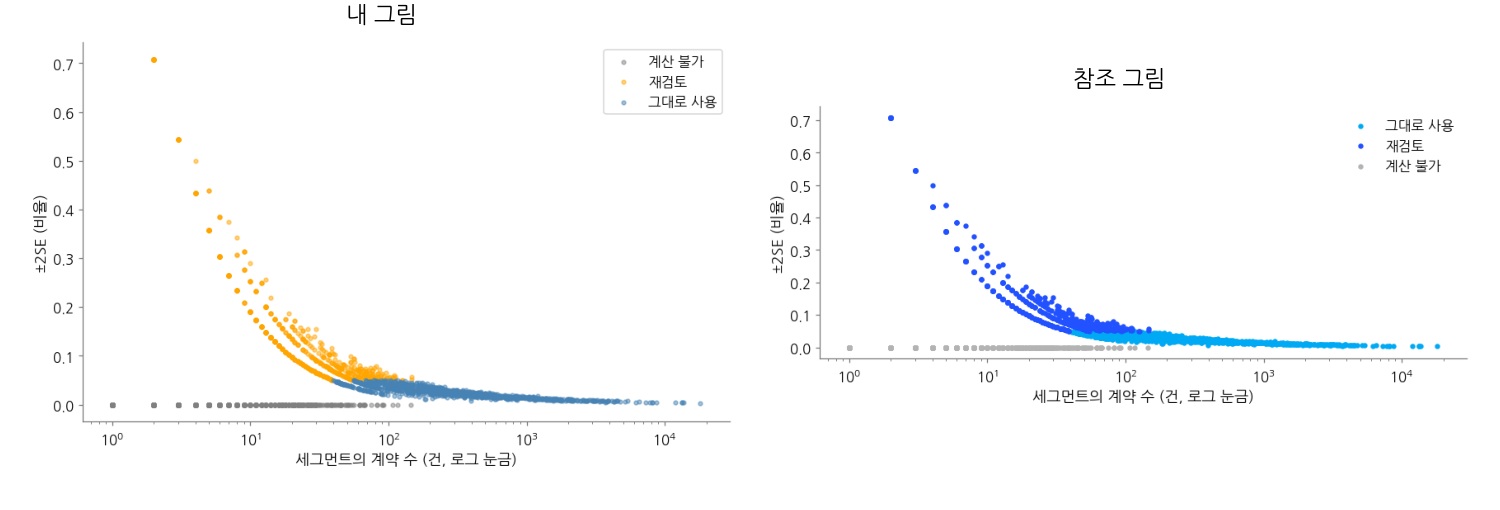

In [8]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
1. 세그먼트 2,323 기준으로 판정 열을 만들거야
세그먼트마다 셋 중 하나를 적어 seg3에 남기고 판정 기준을 아래 기준을 따라줘
계산 불가: 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트
재검토: 남은 세그먼트 중 ±2SE 가 p_all 보다 넓은 세그먼트
그대로 사용 : 나머지 세그먼트

2. 그대로 사용 세그먼트 수 / 단위 개, 정수

3. 재검토, 계산 불가 세그먼트에 속한 계약 수 / 단위 건, 정수
세그먼트 수가 아니라 그 세그먼트들의 n을 더한 값임.

4. 재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 / 단위 건, 정수

5. 계약당 사고 건수 / 단위 건/계약, 소수 여섯 자리까지
이 값만 0/1 변수가 아님, 사고 유무가 아니라 사고 건수 열의 평균임

6. 그래프 / 가로축은 세그먼트의 계약 수 , 세로축은 그 세그먼트의 표준오차 산점도
점: 세그먼트 하나에 점 하나, 2323개
가로축 눈금: 로그 눈금
색: 판정 셋을 색으로 구분하고 범례 작성
가로축 이름: 세그먼트의 계약 수 (건, 로그 눈금)
세로축 이름: ±2SE (비율)

주의: 값 넷을 「이름 = 값 단위」 꼴로 한 행씩 print
그리고 마지막으로 그래프 한장
"""
# --- 여기부터 AI 코드 ---
seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])

invalid = (seg3["k"] == 0) | (seg3["k"] == seg3["n"])

seg3["판정"] = "그대로 사용"
seg3.loc[invalid, "판정"] = "계산 불가"
review_mask = (~invalid) & (seg3["표준오차"] > p_all)
seg3.loc[review_mask, "판정"] = "재검토"

n_use = int((seg3["판정"] == "그대로 사용").sum())
n_contracts = int(seg3.loc[seg3["판정"].isin(["재검토", "계산 불가"]), "n"].sum())
max_n_review = int(seg3.loc[seg3["판정"] == "재검토", "n"].max())
claims_per_contract = df["ClaimNb"].mean()

print(f"그대로 사용 세그먼트 수 = {n_use} 개")
print(f"재검토·계산 불가 세그먼트에 속한 계약 수 = {n_contracts} 건")
print(f"재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 = {max_n_review} 건")
print(f"계약당 사고 건수 = {claims_per_contract:.6f} 건/계약")

colors = {"계산 불가": "gray", "재검토": "orange", "그대로 사용": "steelblue"}
plt.figure(figsize=(8, 5))
for verdict, color in colors.items():
    sub = seg3[seg3["판정"] == verdict]
    plt.scatter(sub["n"], sub["표준오차"], s=10, alpha=0.5, label=verdict, color=color)
plt.xscale("log")
plt.xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
plt.ylabel("±2SE (비율)")
plt.legend()
plt.show()

**브리핑 세 문장** — 아래 세 문장을 이 셀에 그대로 채워 제출합니다. 값과 그림이 모두 채점을 통과한 뒤에 씁니다. 위험 문장에는 사람이 다시 볼 세그먼트에 속한 계약 수를 함께 적어 두면 상품팀이 일의 크기를 바로 봅니다.

> **결론**: 그대로 쓸 세그먼트는 ____ 개이고, 사람이 다시 볼 세그먼트는 ____ 개입니다.
>
> **위험**: ____ — 다시 볼 세그먼트에 속한 계약과 그 계약에 무엇을 적을지 한 문장
>
> **코드가 답을 만드는 방식**: ____ — ±2SE 하나로 어느 기준선을 그었는지 한 문장

**상품팀 답신** — 브리핑 바로 아래에 세 문장을 채웁니다. 브리핑이 우리 팀에 쓰는 글이라면, 답신은 상품팀에 보내는 글입니다.

> **결론**: 요율표에서 그대로 쓰셔도 되는 세그먼트는 ____ 개입니다.
>
> **근거**: ____ — 이 판정을 어떤 기준값으로 구분했는지 한 문장
>
> **한계**: ____ — 다시 볼 세그먼트의 숫자를 지금 어떻게 다뤄야 하는지 한 문장

## 오늘의 정리 — 내일은 기간으로 나눈 사고율로

오늘의 질문은 「계약 하나가 사고를 겪을 확률을 우리 기록에서 얼마로 추정하고, 그 숫자를 요율표의 어느 세그먼트까지 그대로 옮겨 적어도 되는가」였습니다. 한 문장으로 답하면 이렇습니다 — **전체 계약에서는 0.050235 이고, 그 값을 그대로 옮겨 적어도 되는 세그먼트는 ±2SE 가 회사 전체 값보다 좁은 세그먼트뿐입니다.**

| 오늘 물은 것 | 우리가 얻은 답 |
|---|---|
| 전체 계약의 사고 경험률은? | 0.050235 비율 — 수치 최적화가 찾은 값과 k / n 이 같은 값이다 |
| ±2SE 가 0 으로 찍힌 세그먼트는 무엇인가? | 추정값이 안정된 세그먼트가 아니라, 사고가 0건이거나 계약 전부가 사고를 겪어 계산만 0 이 된 세그먼트 759개다 |
| 계약 수가 적은 세그먼트에 적어도 되는 값은? | 값 하나가 아니라 우도로 구한 구간으로 보고한다 — 63건 세그먼트는 그 구간의 좌우 길이가 다르다 |
| 요율표에 그대로 옮길 세그먼트는? | ±2SE 가 회사 전체 값보다 넓은가 하나로 갈라, 넓은 쪽을 사람이 다시 보게 남긴다 |

오늘 남는 결과물은 숫자 하나가 아니라 **판정이 붙은 표 한 장**입니다. 추정값과 ±2SE 구간을 함께 읽는 습관, 그리고 ±2SE 구간이 추정값 자체보다 넓은 세그먼트를 따로 분류하는 규칙이 그 표를 만들었어요.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/MLfunctionbinomial-en.svg" width="560" height="373"/>
<p align="center"><em>▲ 오늘의 요약 — 계약 10건 가운데 사고를 겪은 계약이 1건·3건·6건일 때의 우도 곡선. 최댓값이 0.1 · 0.3 · 0.6 으로 k / n 자리에 그대로 있어도 곡선 셋이 모두 완만해, 추정값과 ±2SE 구간을 함께 보고해야 한다 (출처: Wikimedia Commons, MLfunctionbinomial-en.svg)</em></p>

가로축이 후보 비율이고, 세로축이 그 후보의 우도입니다. 곡선 셋은 사고 1건·3건·6건 순으로 빨강 · 초록 · 파랑이고, 그림 안 범례의 t 가 사고를 겪은 계약 수입니다.

<details class="lms-extra"><summary>숫자로 맞춰 보기 — 미션 3 과 과제를 낸 뒤 펼쳐 보세요</summary>

미션 3 의 구간은 0.020 부터 0.141 까지, 과제에서 그대로 쓸 세그먼트는 960개(전체 계약의 95.8%)입니다.

</details>

## 내일 예고 — 계약마다 기간이 다르다

오늘은 계약이 사고를 겪었는지만 0 과 1 로 셌습니다. 그런데 어떤 계약은 열두 달을 유지했고 어떤 계약은 두 달 만에 끝났어요. 두 계약의 1 을 같은 무게로 세는 것이 맞을까요.

내일은 분석 지표를 **기간으로 나눈 사고율**로 바꾸고, 오늘 접어 둔 `Exposure` 열을 분모로 꺼냅니다. 세그먼트도 마력을 뺀 지역 × 차종으로 넓혀 잡고요. 그러고도 계약 수가 적은 세그먼트는 여전히 적으니, 데이터 바깥의 사전분포(정규화 항)를 더해 그 세그먼트의 추정값을 안정시키는 방법까지가 내일의 몫입니다. 오늘 적은 우도가 그 식 안에 한 항으로 그대로 들어갑니다.

마무리는 두 문장이면 충분합니다. 오늘 채점이 열어 준 완성본과 내 코드가 갈렸던 자리 한 곳, 그리고 그 자리에서 배운 것 한 문장. 팀 채널에 올려 두고 다른 사람의 두 문장을 읽는 것이 오늘의 마지막 복습이에요.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 모형추정 Day 1 완료</h2>
<div style="color:#656565">우도로 값 하나를 추정하고, ±2SE 구간을 기준으로 그 값을 그대로 써도 되는 세그먼트를 구분했습니다.<br/>내일은 계약마다 다른 기간을 값 안에 넣습니다.</div>
</div>

> **[문제] 재검토 세그먼트에 무엇을 적어 보낼까**
>
> 과제에서 만든 표를 상품팀에 넘기려는데, 「재검토」로 판정된 세그먼트에는 적어 보낼 요율이 비어 있습니다. 상품팀은 "요율이 비어 있는 자리가 있으면 시스템에 못 올린다"고 답했어요. (가) 재검토 세그먼트에 그 세그먼트의 사고 경험률을 그대로 적으면 무엇이 문제인지, (나) 대신 무엇을 적어 넣을지 후보 하나와 그 근거를, (다) 그 임시값을 언제 걷어낼 수 있는지를 — 세 문장으로 적어 보세요.